In [1]:
# Cell 1: Import libraries and setup
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
# Cell 2: Initialize wandb API
api = wandb.Api(api_key="6da3cfca616fa8b7e812fc8fcf54ef2a08870da2")

# Your project details
entity = "kirdon6-university-of-copenhagen"
project = "cluster-structure-prediction"

In [3]:
# Cell 3: Helper functions
def extract_model_type(run, config):
    """Extract model type from run name, tags, or config."""
    # Check run name first
    name_lower = run.name.lower()
    if 'mlp' in name_lower:
        return 'MLP'
    elif 'diffusion' in name_lower or 'ddpm' in name_lower:
        return 'Diffusion'
    
    # Check tags
    for tag in run.tags:
        if 'mlp' in tag.lower():
            return 'MLP'
        elif 'diffusion' in tag.lower() or 'ddpm' in tag.lower():
            return 'Diffusion'
    
    # Check config
    model_from_config = config.get('model', '').lower()
    if 'mlp' in model_from_config:
        return 'MLP'
    elif 'diffusion' in model_from_config:
        return 'Diffusion'
    
    return 'Unknown'

def create_model_identifier(row):
    """Create a descriptive identifier for each model configuration."""
    model_type = row['model_type']
    cond_type = row['cond_type']
    pos_type = row['pos_type']
    T = row['T']
    
    if model_type == 'Diffusion' and pd.notna(T):
        return f"{model_type}_T{int(T)}_{cond_type}_{pos_type}"
    else:
        return f"{model_type}_{cond_type}_{pos_type}"

In [4]:
# Cell 4: Fetch runs from wandb
print(f"Fetching runs from {entity}/{project}...")
runs = api.runs(f"{entity}/{project}")

print(f"Found {len(runs)} total runs")

# Extract run data
runs_data = []

for run in runs:
    # Skip runs without test metrics
    if not any(key.startswith('test/') for key in run.summary.keys()):
        continue
        
    # Extract run information
    config = run.config
    summary = run.summary
    
    run_info = {
        'run_id': run.id,
        'run_name': run.name,
        'tags': run.tags,
        'state': run.state,
        
        # Extract key parameters from config
        'model_type': extract_model_type(run, config),
        'cond_type': config.get('Model_config', {}).get('cond_type', 'unknown'),
        'pos_type': config.get('Model_config', {}).get('model_type', 'unknown'),
        'T': config.get('Model_config', {}).get('T', None),
        'epochs': config.get('Train_config', {}).get('epochs', None),
        'batch_size': config.get('Train_config', {}).get('batch_size', None),
        'learning_rate': config.get('Train_config', {}).get('learning_rate', None),
        
        # Extract test metrics
        'test_mae': summary.get('test/mae', None),
        'test_hausdorff': summary.get('test/hausdorff', None),
        'test_optimized_mae': summary.get('test/optimized_mae', None),
        'test_optimized_typed_mae': summary.get('test/optimized_typed_mae', None),
        'test_atom_type_accuracy': summary.get('test/atom_type_accuracy', None),
    }
    
    # Only add runs that have at least some test metrics
    if any(run_info[key] is not None for key in ['test_mae', 'test_hausdorff', 'test_optimized_mae']):
        runs_data.append(run_info)

print(f"Collected {len(runs_data)} runs with test metrics")

Fetching runs from kirdon6-university-of-copenhagen/cluster-structure-prediction...
Found 12 total runs
Collected 12 runs with test metrics


In [5]:
# Cell 5: Create DataFrame and add model configuration identifier
df = pd.DataFrame(runs_data)

# Remove runs without basic test metrics
df = df.dropna(subset=['test_mae'])

# Create model configuration identifier
df['model_config'] = df.apply(create_model_identifier, axis=1)

print(f"Final dataset: {len(df)} runs")
print(f"Model types: {df['model_type'].unique()}")
print(f"Conditioning types: {df['cond_type'].unique()}")
print(f"Position types: {df['pos_type'].unique()}")
print(f"Diffusion steps (T): {df['T'].unique()}")
print(f"Model configurations: {df['model_config'].unique()}")

Final dataset: 12 runs
Model types: ['Diffusion' 'MLP']
Conditioning types: ['xPDF' 'xrd']
Position types: ['pos_abs' 'pos_frac']
Diffusion steps (T): [1000.  100.   nan]
Model configurations: ['Diffusion_T1000_xPDF_pos_abs' 'Diffusion_T100_xPDF_pos_frac'
 'Diffusion_T1000_xPDF_pos_frac' 'Diffusion_T100_xrd_pos_abs'
 'Diffusion_T1000_xrd_pos_abs' 'Diffusion_T100_xrd_pos_frac'
 'Diffusion_T1000_xrd_pos_frac' 'Diffusion_T100_xPDF_pos_abs'
 'MLP_xPDF_pos_abs' 'MLP_xPDF_pos_frac' 'MLP_xrd_pos_abs'
 'MLP_xrd_pos_frac']


In [8]:
# Cell 6: Display first few rows to check data
display_cols = ['run_name', 'model_type', 'cond_type', 'pos_type', 'T', 'test_mae', 'test_hausdorff', 'test_optimized_mae', 'test_optimized_typed_mae', 'test_atom_type_accuracy']
df[display_cols].head(12)

,run_name,model_type,cond_type,pos_type,T,test_mae,test_hausdorff,test_optimized_mae,test_optimized_typed_mae,test_atom_type_accuracy
0,structure-prediction,Diffusion,xPDF,pos_abs,1000.0,7.835778,9.431829,3.121213,11.605562,55.710316
1,structure-prediction,Diffusion,xPDF,pos_frac,100.0,1.678466,1.476754,0.633003,6.496316,69.670631
2,structure-prediction,Diffusion,xPDF,pos_frac,1000.0,1.794634,1.763170,0.674289,6.618045,69.035706
3,structure-prediction,Diffusion,xrd,pos_abs,100.0,6.135640,4.366223,2.355033,14.062387,40.123016
4,structure-prediction,Diffusion,xrd,pos_abs,1000.0,9.916530,17.566104,4.703341,16.392950,40.777775
5,structure-prediction,Diffusion,xrd,pos_frac,100.0,1.740576,1.540006,0.661470,10.148139,52.063488
6,structure-prediction,Diffusion,xrd,pos_frac,1000.0,1.863915,2.006432,0.728666,10.187613,52.297615
7,structure-prediction,Diffusion,xPDF,pos_abs,100.0,5.975975,4.322498,2.399643,9.723510,61.238091
8,structure-prediction,MLP,xPDF,pos_abs,NaN,5.058556,6.411598,4.845307,20.960515,15.694444
9,structure-prediction,MLP,xPDF,pos_frac,NaN,1.279220,1.935531,1.218674,17.661285,14.500000


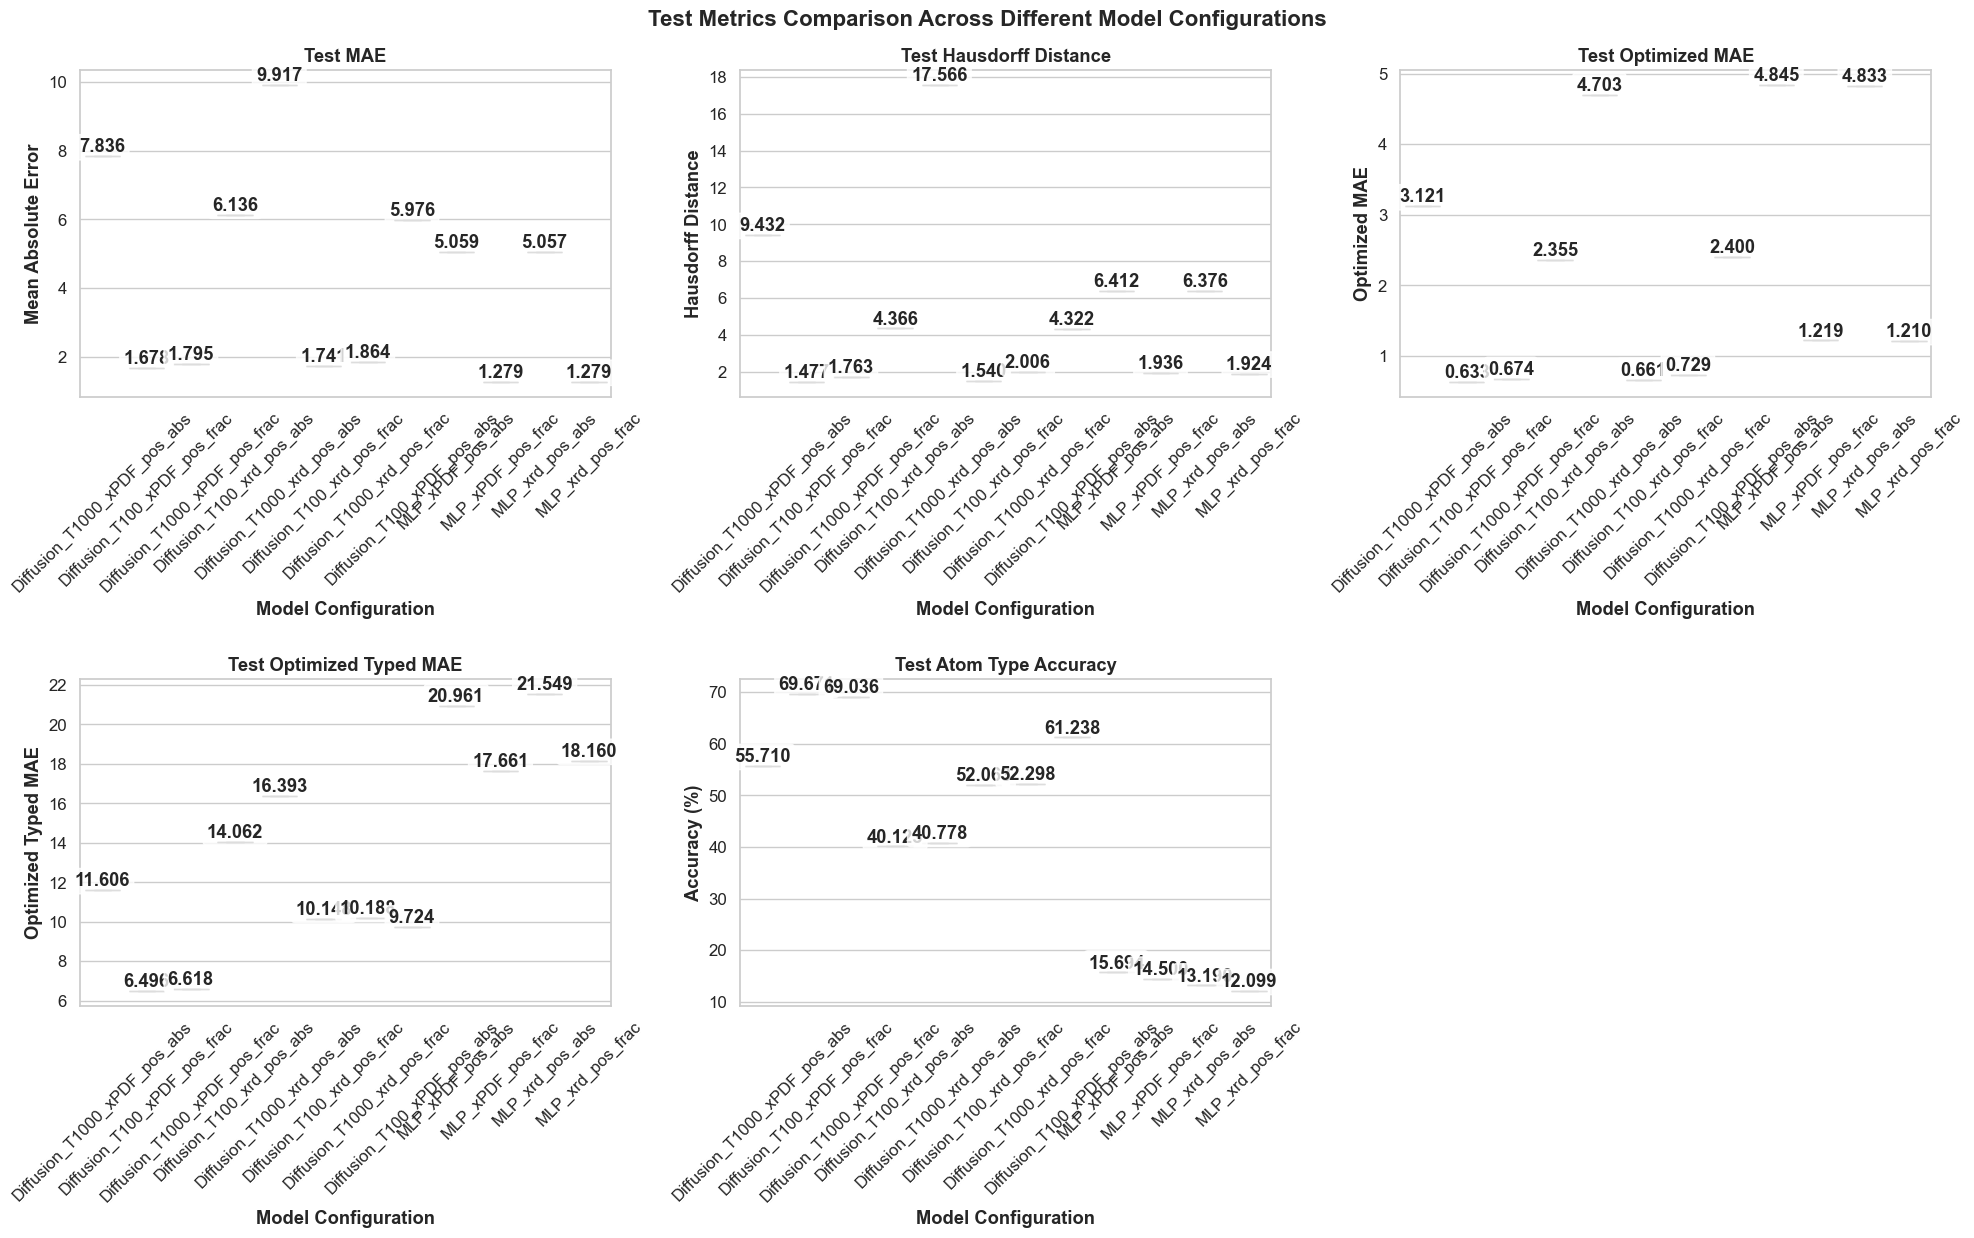

In [9]:
# Cell 7: Main comparison plot
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Test Metrics Comparison Across Different Model Configurations', 
             fontsize=16, fontweight='bold', y=0.98)

# Define metrics to plot
metrics = [
    {'column': 'test_mae', 'title': 'Test MAE', 'ylabel': 'Mean Absolute Error'},
    {'column': 'test_hausdorff', 'title': 'Test Hausdorff Distance', 'ylabel': 'Hausdorff Distance'},
    {'column': 'test_optimized_mae', 'title': 'Test Optimized MAE', 'ylabel': 'Optimized MAE'},
    {'column': 'test_optimized_typed_mae', 'title': 'Test Optimized Typed MAE', 'ylabel': 'Optimized Typed MAE'},
    {'column': 'test_atom_type_accuracy', 'title': 'Test Atom Type Accuracy', 'ylabel': 'Accuracy (%)'},
]

# Flatten axes for easier indexing
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    # Filter out None values for this metric
    metric_df = df.dropna(subset=[metric['column']])
    
    if len(metric_df) == 0:
        ax.text(0.5, 0.5, f"No data for {metric['title']}", 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(metric['title'])
        continue
    
    # Create box plot
    sns.boxplot(data=metric_df, x='model_config', y=metric['column'], ax=ax)
    
    # Customize the plot
    ax.set_title(metric['title'], fontweight='bold')
    ax.set_ylabel(metric['ylabel'], fontweight='bold')
    ax.set_xlabel('Model Configuration', fontweight='bold')
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)
    
    # Add value annotations
    for i, config in enumerate(metric_df['model_config'].unique()):
        config_data = metric_df[metric_df['model_config'] == config][metric['column']]
        if len(config_data) > 0:
            mean_val = config_data.mean()
            ax.text(i, mean_val, f'{mean_val:.3f}', 
                   ha='center', va='bottom', fontweight='bold', 
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Remove the empty subplot
axes_flat[5].remove()

plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.15)
plt.show()

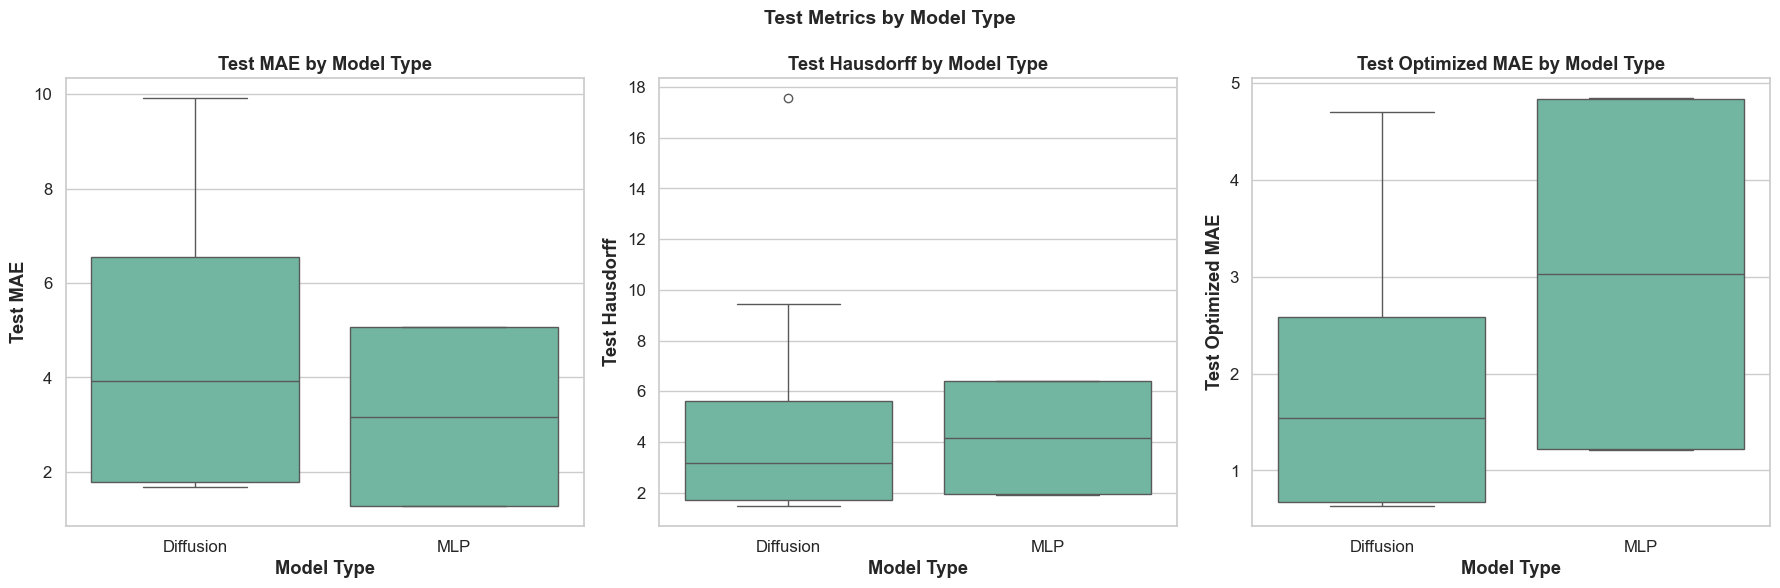

In [10]:
# Cell 8: Model Type Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Test Metrics by Model Type', fontsize=14, fontweight='bold')

metrics = ['test_mae', 'test_hausdorff', 'test_optimized_mae']
metric_names = ['Test MAE', 'Test Hausdorff', 'Test Optimized MAE']

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    metric_df = df.dropna(subset=[metric])
    if len(metric_df) > 0:
        sns.boxplot(data=metric_df, x='model_type', y=metric, ax=axes[idx])
        axes[idx].set_title(f'{name} by Model Type', fontweight='bold')
        axes[idx].set_ylabel(name, fontweight='bold')
        axes[idx].set_xlabel('Model Type', fontweight='bold')

plt.tight_layout()
plt.show()

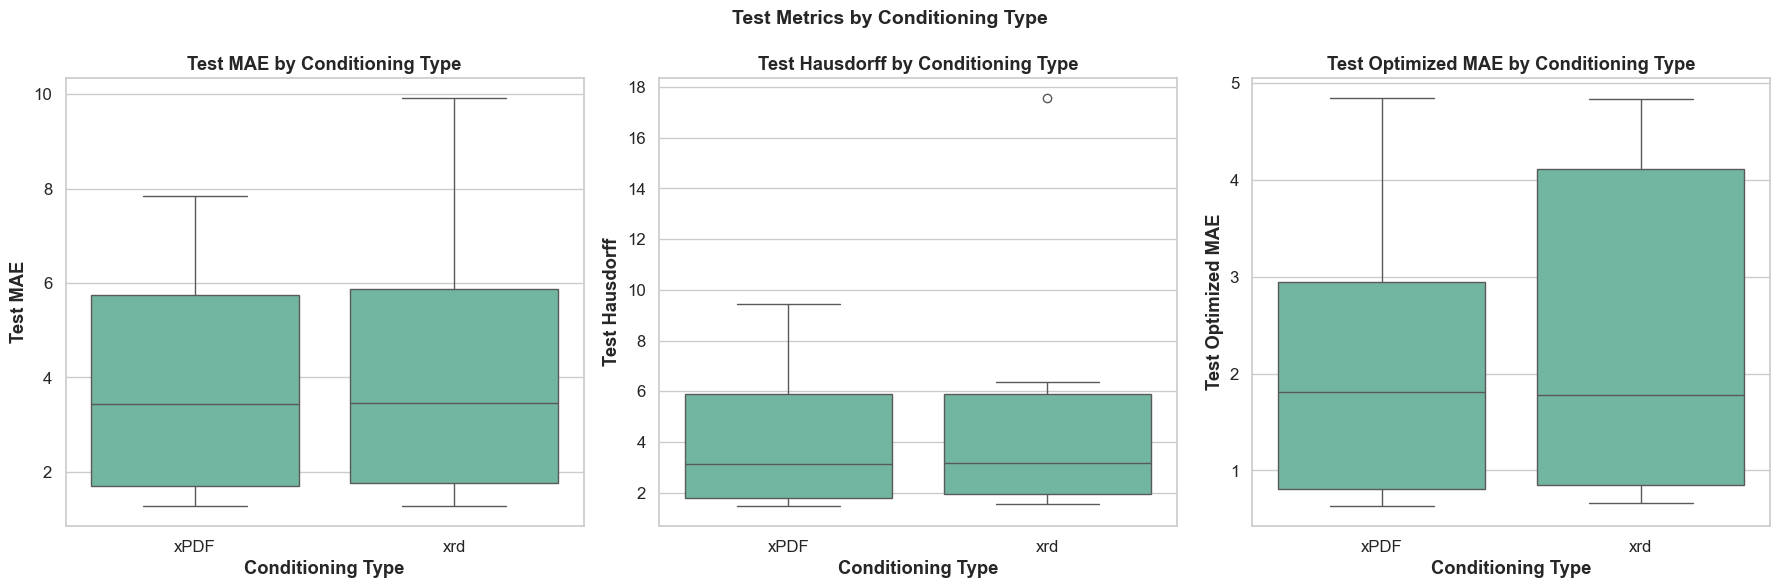

In [11]:
# Cell 9: Conditioning Type Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Test Metrics by Conditioning Type', fontsize=14, fontweight='bold')

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    metric_df = df.dropna(subset=[metric])
    if len(metric_df) > 0:
        sns.boxplot(data=metric_df, x='cond_type', y=metric, ax=axes[idx])
        axes[idx].set_title(f'{name} by Conditioning Type', fontweight='bold')
        axes[idx].set_ylabel(name, fontweight='bold')
        axes[idx].set_xlabel('Conditioning Type', fontweight='bold')

plt.tight_layout()
plt.show()

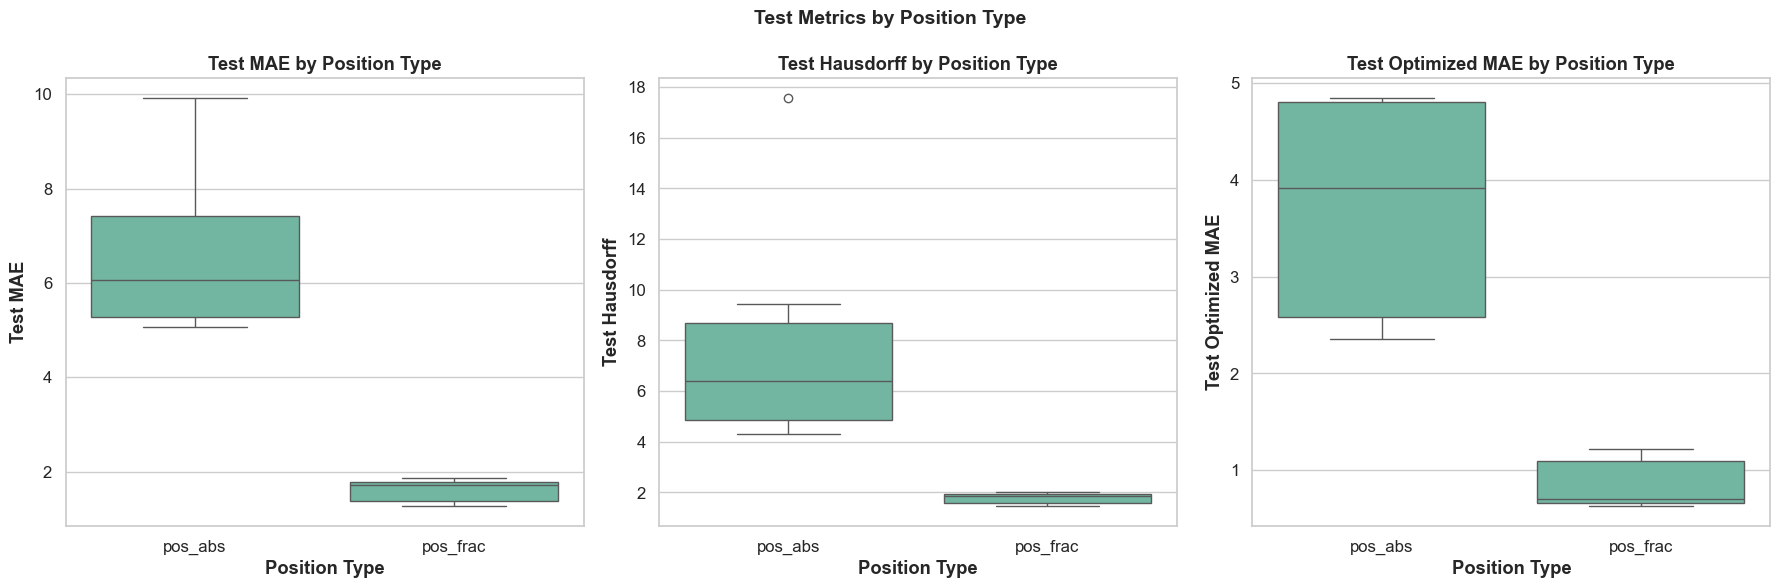

In [12]:
# Cell 10: Position Type Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Test Metrics by Position Type', fontsize=14, fontweight='bold')

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    metric_df = df.dropna(subset=[metric])
    if len(metric_df) > 0:
        sns.boxplot(data=metric_df, x='pos_type', y=metric, ax=axes[idx])
        axes[idx].set_title(f'{name} by Position Type', fontweight='bold')
        axes[idx].set_ylabel(name, fontweight='bold')
        axes[idx].set_xlabel('Position Type', fontweight='bold')

plt.tight_layout()
plt.show()

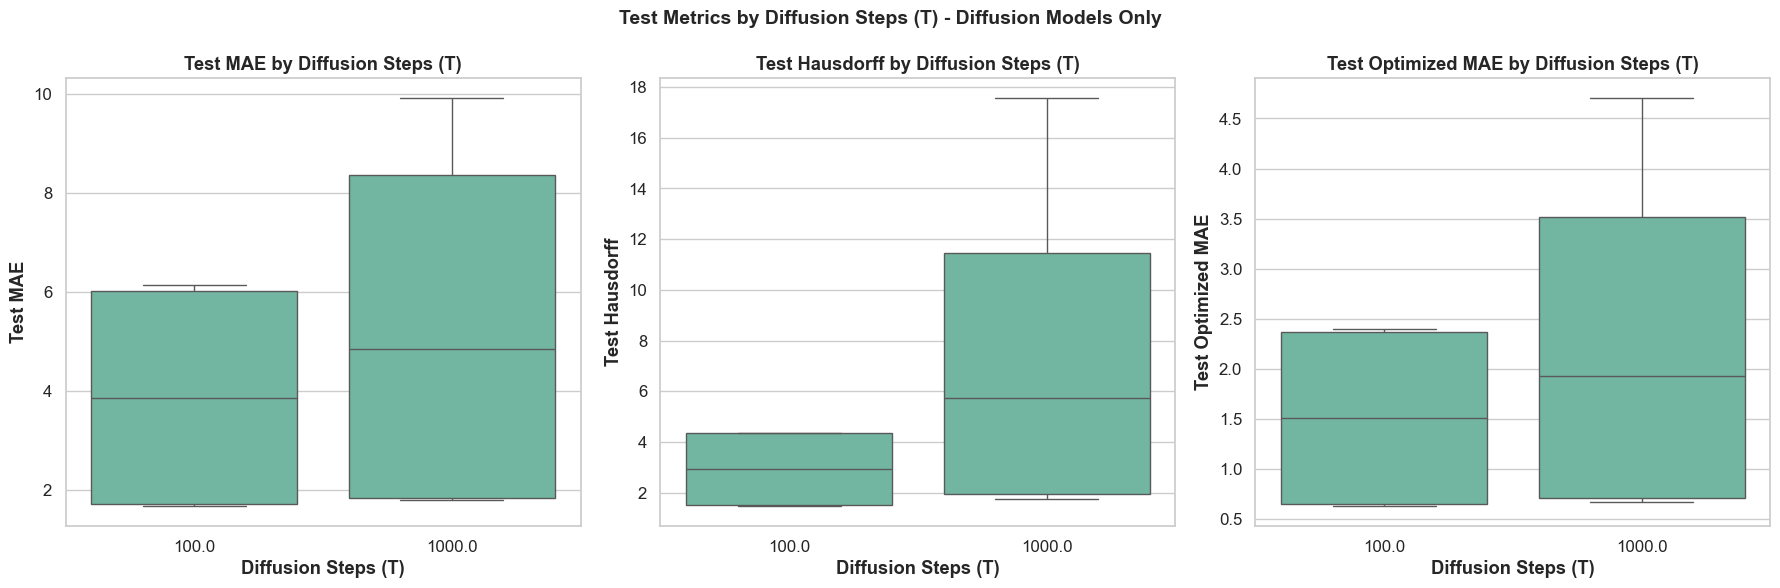

In [13]:
# Cell 11: Diffusion Steps Comparison (T values) - Only for diffusion models
diffusion_df = df[df['model_type'] == 'Diffusion'].dropna(subset=['T'])

if len(diffusion_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Test Metrics by Diffusion Steps (T) - Diffusion Models Only', fontsize=14, fontweight='bold')

    for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
        metric_df = diffusion_df.dropna(subset=[metric])
        if len(metric_df) > 0:
            sns.boxplot(data=metric_df, x='T', y=metric, ax=axes[idx])
            axes[idx].set_title(f'{name} by Diffusion Steps (T)', fontweight='bold')
            axes[idx].set_ylabel(name, fontweight='bold')
            axes[idx].set_xlabel('Diffusion Steps (T)', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No diffusion model data found for T comparison")

In [14]:
# Cell 12: Summary Statistics Table
summary_stats = []

for config in df['model_config'].unique():
    config_df = df[df['model_config'] == config]
    
    stats = {
        'Model_Config': config,
        'Runs': len(config_df),
        'MAE_mean': config_df['test_mae'].mean(),
        'MAE_std': config_df['test_mae'].std(),
        'Hausdorff_mean': config_df['test_hausdorff'].mean() if config_df['test_hausdorff'].notna().any() else None,
        'Hausdorff_std': config_df['test_hausdorff'].std() if config_df['test_hausdorff'].notna().any() else None,
        'Optimized_MAE_mean': config_df['test_optimized_mae'].mean() if config_df['test_optimized_mae'].notna().any() else None,
        'Optimized_MAE_std': config_df['test_optimized_mae'].std() if config_df['test_optimized_mae'].notna().any() else None,
        'Atom_Accuracy_mean': config_df['test_atom_type_accuracy'].mean() if config_df['test_atom_type_accuracy'].notna().any() else None,
        'Atom_Accuracy_std': config_df['test_atom_type_accuracy'].std() if config_df['test_atom_type_accuracy'].notna().any() else None,
    }
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
print("Summary Statistics by Model Configuration:")
display(summary_df.round(4))

Summary Statistics by Model Configuration:


,Model_Config,Runs,MAE_mean,MAE_std,Hausdorff_mean,Hausdorff_std,Optimized_MAE_mean,Optimized_MAE_std,Atom_Accuracy_mean,Atom_Accuracy_std
0,Diffusion_T1000_xPDF_pos_abs,1,7.8358,NaN,9.4318,NaN,3.1212,NaN,55.7103,NaN
1,Diffusion_T100_xPDF_pos_frac,1,1.6785,NaN,1.4768,NaN,0.6330,NaN,69.6706,NaN
2,Diffusion_T1000_xPDF_pos_frac,1,1.7946,NaN,1.7632,NaN,0.6743,NaN,69.0357,NaN
3,Diffusion_T100_xrd_pos_abs,1,6.1356,NaN,4.3662,NaN,2.3550,NaN,40.1230,NaN
4,Diffusion_T1000_xrd_pos_abs,1,9.9165,NaN,17.5661,NaN,4.7033,NaN,40.7778,NaN
5,Diffusion_T100_xrd_pos_frac,1,1.7406,NaN,1.5400,NaN,0.6615,NaN,52.0635,NaN
6,Diffusion_T1000_xrd_pos_frac,1,1.8639,NaN,2.0064,NaN,0.7287,NaN,52.2976,NaN
7,Diffusion_T100_xPDF_pos_abs,1,5.9760,NaN,4.3225,NaN,2.3996,NaN,61.2381,NaN
8,MLP_xPDF_pos_abs,1,5.0586,NaN,6.4116,NaN,4.8453,NaN,15.6944,NaN
9,MLP_xPDF_pos_frac,1,1.2792,NaN,1.9355,NaN,1.2187,NaN,14.5000,NaN


In [15]:
# Cell 13: Save summary to CSV
summary_df.to_csv("test_metrics_summary.csv", index=False)
print("Summary saved to test_metrics_summary.csv")

Summary saved to test_metrics_summary.csv


In [17]:
# Cell 14: Optional - Show individual run details for debugging
print("Individual run details:")
display_cols = ['run_name', 'model_config', 'test_mae', 'test_hausdorff', 'test_optimized_mae', 'test_atom_type_accuracy']
display(df[display_cols].sort_values('test_optimized_mae'))

Individual run details:


,run_name,model_config,test_mae,test_hausdorff,test_optimized_mae,test_atom_type_accuracy
1,structure-prediction,Diffusion_T100_xPDF_pos_frac,1.678466,1.476754,0.633003,69.670631
5,structure-prediction,Diffusion_T100_xrd_pos_frac,1.740576,1.540006,0.661470,52.063488
2,structure-prediction,Diffusion_T1000_xPDF_pos_frac,1.794634,1.763170,0.674289,69.035706
6,structure-prediction,Diffusion_T1000_xrd_pos_frac,1.863915,2.006432,0.728666,52.297615
11,structure-prediction,MLP_xrd_pos_frac,1.279013,1.923905,1.209804,12.099206
9,structure-prediction,MLP_xPDF_pos_frac,1.279220,1.935531,1.218674,14.500000
3,structure-prediction,Diffusion_T100_xrd_pos_abs,6.135640,4.366223,2.355033,40.123016
7,structure-prediction,Diffusion_T100_xPDF_pos_abs,5.975975,4.322498,2.399643,61.238091
0,structure-prediction,Diffusion_T1000_xPDF_pos_abs,7.835778,9.431829,3.121213,55.710316
4,structure-prediction,Diffusion_T1000_xrd_pos_abs,9.916530,17.566104,4.703341,40.777775


In [22]:
# Cell 15: Updated model identifier function with better naming
def create_model_identifier_simple(row):
    """Create a simple identifier for model type and T value with proper formatting."""
    model_type = row['model_type']
    T = row['T']
    
    if model_type == 'Diffusion' and pd.notna(T):
        return f"Diffusion (T={int(T)})"
    else:
        return model_type

# Add simple model identifier with new formatting
df['model_simple'] = df.apply(create_model_identifier_simple, axis=1)

# Define the combinations we want to plot
combinations = [
    {'cond': 'xPDF', 'pos': 'pos_abs', 'title': 'xPDF with Absolute Coordinates'},
    {'cond': 'xPDF', 'pos': 'pos_frac', 'title': 'xPDF with Fractional Coordinates'},
    {'cond': 'xrd', 'pos': 'pos_abs', 'title': 'XRD with Absolute Coordinates'},
    {'cond': 'xrd', 'pos': 'pos_frac', 'title': 'XRD with Fractional Coordinates'}
]

print("Available data combinations:")
for combo in combinations:
    subset = df[(df['cond_type'] == combo['cond']) & (df['pos_type'] == combo['pos'])]
    print(f"{combo['title']}: {len(subset)} runs")
    if len(subset) > 0:
        print(f"  Models: {subset['model_simple'].unique()}")
    print()

Available data combinations:
xPDF with Absolute Coordinates: 3 runs
  Models: ['Diffusion (T=1000)' 'Diffusion (T=100)' 'MLP']

xPDF with Fractional Coordinates: 3 runs
  Models: ['Diffusion (T=100)' 'Diffusion (T=1000)' 'MLP']

XRD with Absolute Coordinates: 3 runs
  Models: ['Diffusion (T=100)' 'Diffusion (T=1000)' 'MLP']

XRD with Fractional Coordinates: 3 runs
  Models: ['Diffusion (T=100)' 'Diffusion (T=1000)' 'MLP']



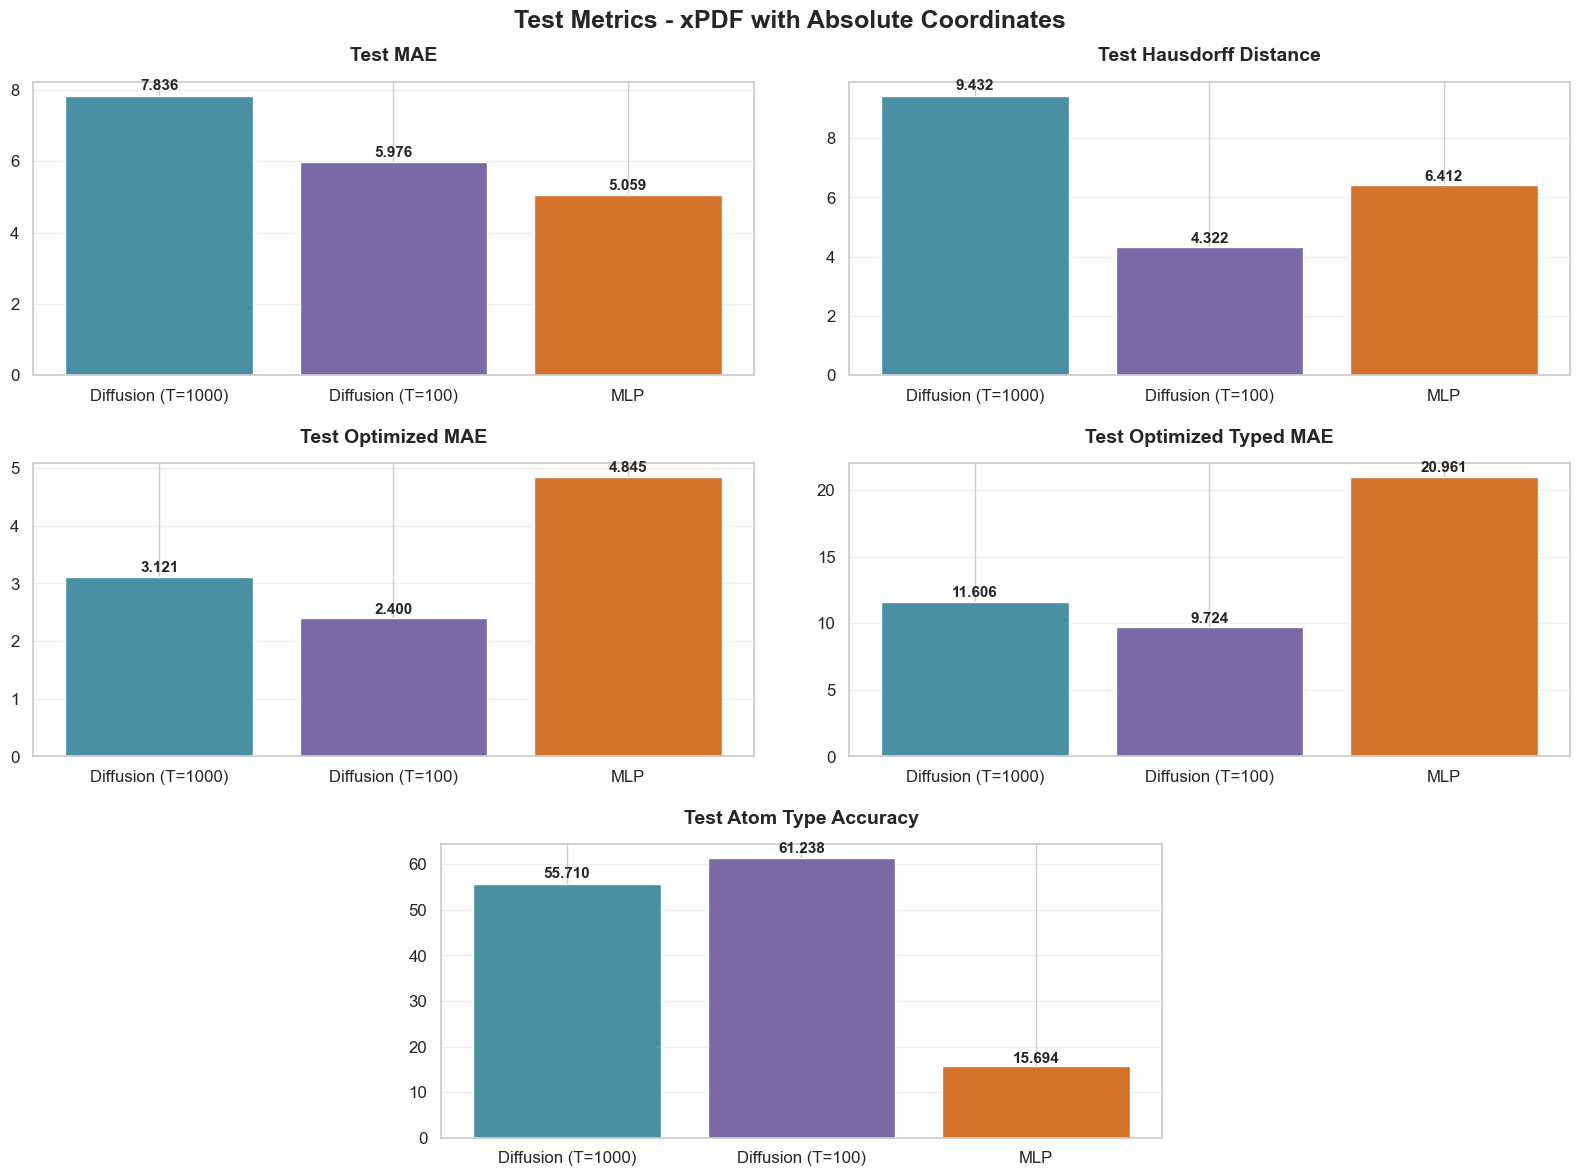

In [44]:
# Cell 16: Improved Plot for xPDF + Absolute Coordinates - Modern Colors
combo = combinations[0]  # xPDF + pos_abs
subset_df = df[(df['cond_type'] == combo['cond']) & (df['pos_type'] == combo['pos'])]

if len(subset_df) > 0:
    # Aggregate data by model type (taking mean if multiple runs)
    model_stats = []
    for model in subset_df['model_simple'].unique():
        model_data = subset_df[subset_df['model_simple'] == model]
        stats = {
            'Model': model,
            'Test MAE': model_data['test_mae'].mean(),
            'Test Hausdorff': model_data['test_hausdorff'].mean() if model_data['test_hausdorff'].notna().any() else 0,
            'Test Optimized MAE': model_data['test_optimized_mae'].mean() if model_data['test_optimized_mae'].notna().any() else 0,
            'Test Optimized Typed MAE': model_data['test_optimized_typed_mae'].mean() if model_data['test_optimized_typed_mae'].notna().any() else 0,
            'Test Atom Type Accuracy': model_data['test_atom_type_accuracy'].mean() if model_data['test_atom_type_accuracy'].notna().any() else 0,
        }
        model_stats.append(stats)
    
    model_df = pd.DataFrame(model_stats)
    
    # Create the plot using subplot2grid for better control
    fig = plt.figure(figsize=(16, 12))
    
    # Modern, muted color palette
    colors = ['#4A90A4', '#7B68A6', '#D67229']  # Muted teal, purple, orange
    
    # Row 1: Test MAE and Test Hausdorff
    ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=2)
    bars1 = ax1.bar(model_df['Model'], model_df['Test MAE'], color=colors[:len(model_df)])
    ax1.set_title('Test MAE', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars1, model_df['Test MAE']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
    bars2 = ax2.bar(model_df['Model'], model_df['Test Hausdorff'], color=colors[:len(model_df)])
    ax2.set_title('Test Hausdorff Distance', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars2, model_df['Test Hausdorff']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 2: Test Optimized MAE and Test Optimized Typed MAE
    ax3 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
    bars3 = ax3.bar(model_df['Model'], model_df['Test Optimized MAE'], color=colors[:len(model_df)])
    ax3.set_title('Test Optimized MAE', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars3, model_df['Test Optimized MAE']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax4 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
    bars4 = ax4.bar(model_df['Model'], model_df['Test Optimized Typed MAE'], color=colors[:len(model_df)])
    ax4.set_title('Test Optimized Typed MAE', fontsize=14, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars4, model_df['Test Optimized Typed MAE']):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 3: Test Atom Type Accuracy (centered, same size as others)
    ax5 = plt.subplot2grid((3, 4), (2, 1), colspan=2)  # Centered in the bottom row
    bars5 = ax5.bar(model_df['Model'], model_df['Test Atom Type Accuracy'], color=colors[:len(model_df)])
    ax5.set_title('Test Atom Type Accuracy', fontsize=14, fontweight='bold', pad=15)
    ax5.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars5, model_df['Test Atom Type Accuracy']):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Overall title
    fig.suptitle(f'Test Metrics - {combo["title"]}', 
                fontsize=18, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
    plt.show()
else:
    print(f"No data found for {combo['title']}")

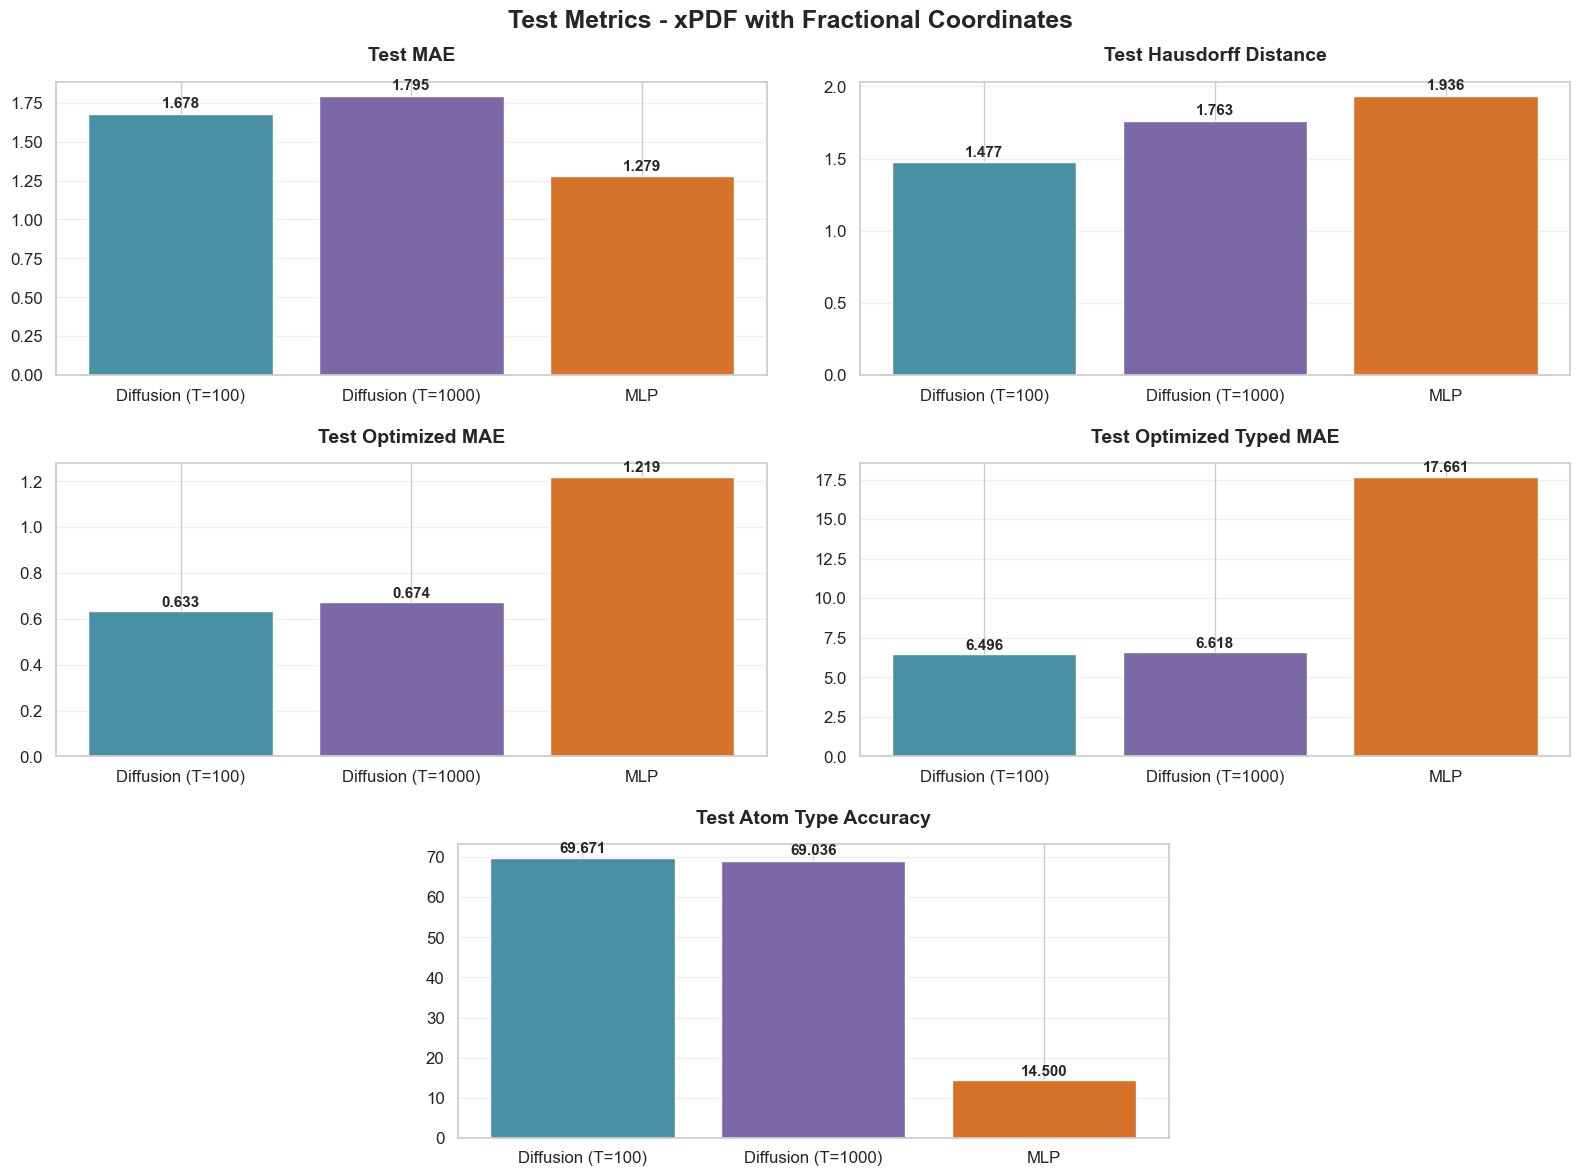

In [45]:
# Cell 17: Improved Plot for xPDF + Fractional Coordinates - Modern Colors
combo = combinations[1]  # xPDF + pos_frac
subset_df = df[(df['cond_type'] == combo['cond']) & (df['pos_type'] == combo['pos'])]

if len(subset_df) > 0:
    # Aggregate data by model type
    model_stats = []
    for model in subset_df['model_simple'].unique():
        model_data = subset_df[subset_df['model_simple'] == model]
        stats = {
            'Model': model,
            'Test MAE': model_data['test_mae'].mean(),
            'Test Hausdorff': model_data['test_hausdorff'].mean() if model_data['test_hausdorff'].notna().any() else 0,
            'Test Optimized MAE': model_data['test_optimized_mae'].mean() if model_data['test_optimized_mae'].notna().any() else 0,
            'Test Optimized Typed MAE': model_data['test_optimized_typed_mae'].mean() if model_data['test_optimized_typed_mae'].notna().any() else 0,
            'Test Atom Type Accuracy': model_data['test_atom_type_accuracy'].mean() if model_data['test_atom_type_accuracy'].notna().any() else 0,
        }
        model_stats.append(stats)
    
    model_df = pd.DataFrame(model_stats)
    
    # Create the plot using subplot2grid
    fig = plt.figure(figsize=(16, 12))
    colors = ['#4A90A4', '#7B68A6', '#D67229']  # Modern muted colors
    
    # Row 1
    ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=2)
    bars1 = ax1.bar(model_df['Model'], model_df['Test MAE'], color=colors[:len(model_df)])
    ax1.set_title('Test MAE', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars1, model_df['Test MAE']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
    bars2 = ax2.bar(model_df['Model'], model_df['Test Hausdorff'], color=colors[:len(model_df)])
    ax2.set_title('Test Hausdorff Distance', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars2, model_df['Test Hausdorff']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 2
    ax3 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
    bars3 = ax3.bar(model_df['Model'], model_df['Test Optimized MAE'], color=colors[:len(model_df)])
    ax3.set_title('Test Optimized MAE', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars3, model_df['Test Optimized MAE']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax4 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
    bars4 = ax4.bar(model_df['Model'], model_df['Test Optimized Typed MAE'], color=colors[:len(model_df)])
    ax4.set_title('Test Optimized Typed MAE', fontsize=14, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars4, model_df['Test Optimized Typed MAE']):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 3 (centered, same size)
    ax5 = plt.subplot2grid((3, 4), (2, 1), colspan=2)
    bars5 = ax5.bar(model_df['Model'], model_df['Test Atom Type Accuracy'], color=colors[:len(model_df)])
    ax5.set_title('Test Atom Type Accuracy', fontsize=14, fontweight='bold', pad=15)
    ax5.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars5, model_df['Test Atom Type Accuracy']):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    fig.suptitle(f'Test Metrics - {combo["title"]}', 
                fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
    plt.show()
else:
    print(f"No data found for {combo['title']}")

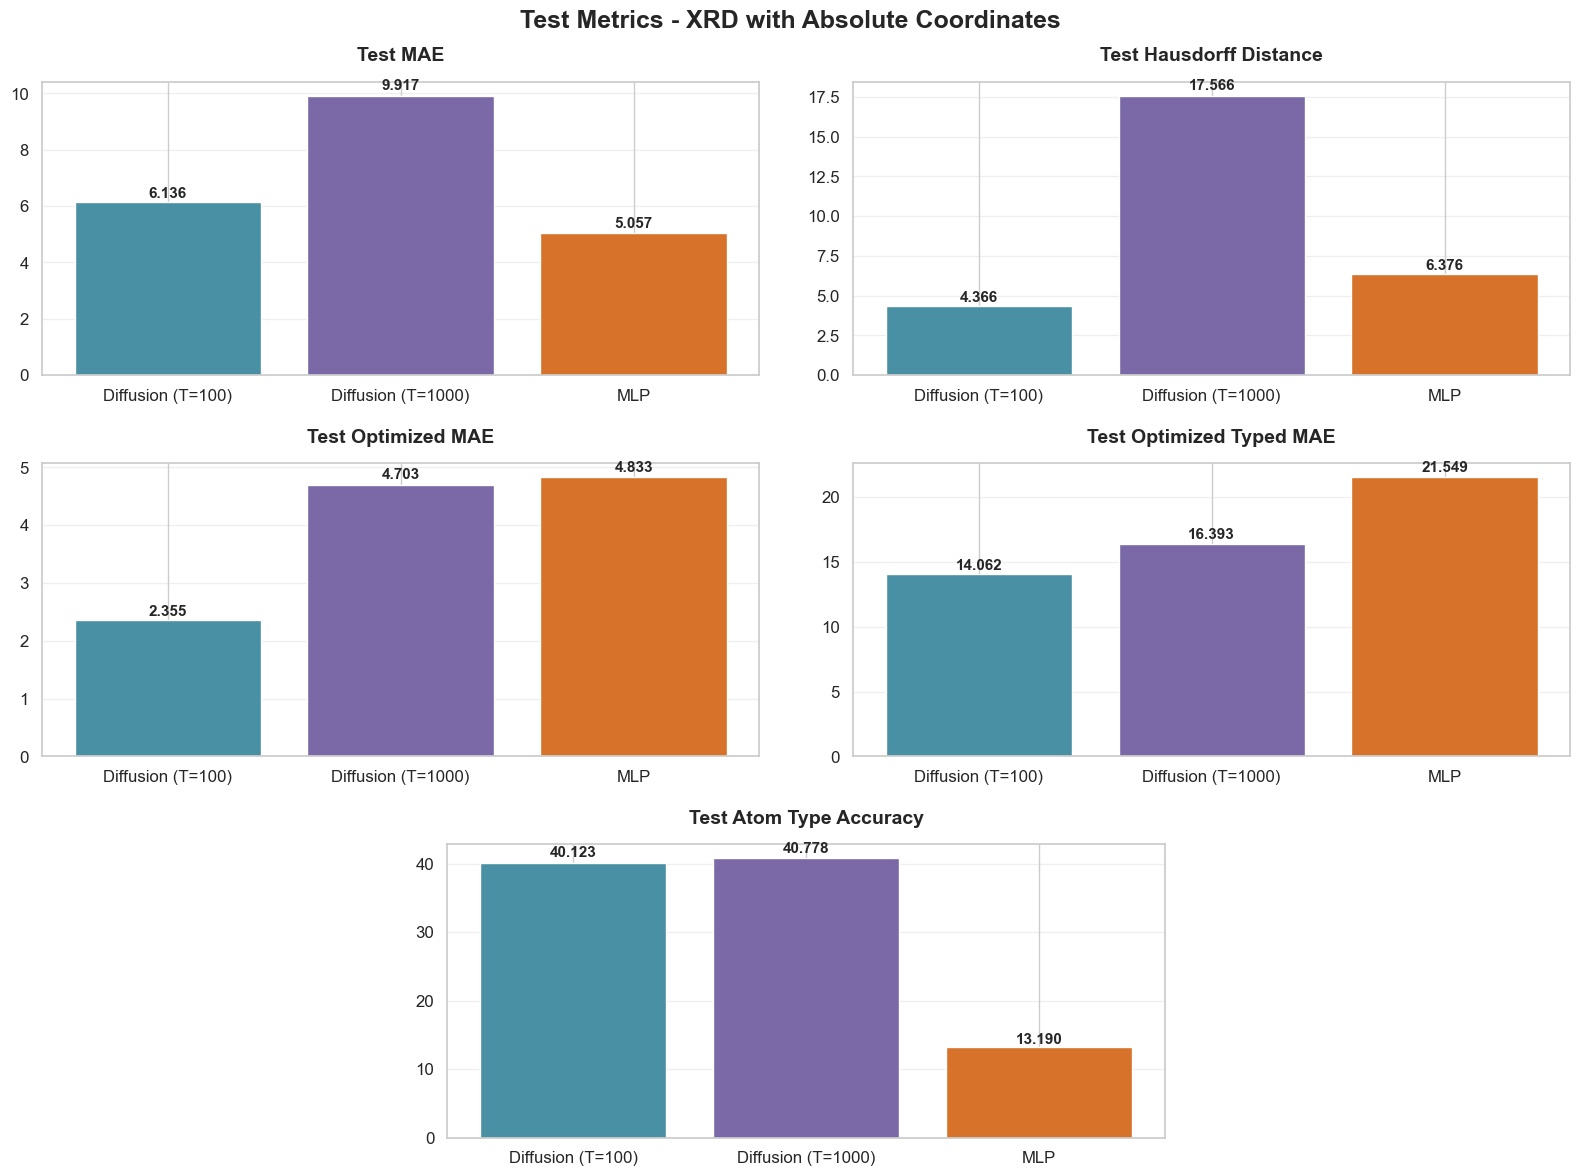

In [47]:
# Cell 18: Improved Plot for XRD + Absolute Coordinates - Modern Colors
combo = combinations[2]  # XRD + pos_abs
subset_df = df[(df['cond_type'] == combo['cond']) & (df['pos_type'] == combo['pos'])]

if len(subset_df) > 0:
    # Aggregate data by model type
    model_stats = []
    for model in subset_df['model_simple'].unique():
        model_data = subset_df[subset_df['model_simple'] == model]
        stats = {
            'Model': model,
            'Test MAE': model_data['test_mae'].mean(),
            'Test Hausdorff': model_data['test_hausdorff'].mean() if model_data['test_hausdorff'].notna().any() else 0,
            'Test Optimized MAE': model_data['test_optimized_mae'].mean() if model_data['test_optimized_mae'].notna().any() else 0,
            'Test Optimized Typed MAE': model_data['test_optimized_typed_mae'].mean() if model_data['test_optimized_typed_mae'].notna().any() else 0,
            'Test Atom Type Accuracy': model_data['test_atom_type_accuracy'].mean() if model_data['test_atom_type_accuracy'].notna().any() else 0,
        }
        model_stats.append(stats)
    
    model_df = pd.DataFrame(model_stats)
    
    # Create the plot using subplot2grid
    fig = plt.figure(figsize=(16, 12))
    colors = ['#4A90A4', '#7B68A6', '#D67229']  # Modern muted colors
    
    # Row 1
    ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=2)
    bars1 = ax1.bar(model_df['Model'], model_df['Test MAE'], color=colors[:len(model_df)])
    ax1.set_title('Test MAE', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars1, model_df['Test MAE']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
    bars2 = ax2.bar(model_df['Model'], model_df['Test Hausdorff'], color=colors[:len(model_df)])
    ax2.set_title('Test Hausdorff Distance', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars2, model_df['Test Hausdorff']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 2
    ax3 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
    bars3 = ax3.bar(model_df['Model'], model_df['Test Optimized MAE'], color=colors[:len(model_df)])
    ax3.set_title('Test Optimized MAE', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars3, model_df['Test Optimized MAE']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax4 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
    bars4 = ax4.bar(model_df['Model'], model_df['Test Optimized Typed MAE'], color=colors[:len(model_df)])
    ax4.set_title('Test Optimized Typed MAE', fontsize=14, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars4, model_df['Test Optimized Typed MAE']):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 3 (centered, same size)
    ax5 = plt.subplot2grid((3, 4), (2, 1), colspan=2)
    bars5 = ax5.bar(model_df['Model'], model_df['Test Atom Type Accuracy'], color=colors[:len(model_df)])
    ax5.set_title('Test Atom Type Accuracy', fontsize=14, fontweight='bold', pad=15)
    ax5.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars5, model_df['Test Atom Type Accuracy']):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    fig.suptitle(f'Test Metrics - {combo["title"]}', 
                fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
    plt.show()
else:
    print(f"No data found for {combo['title']}")

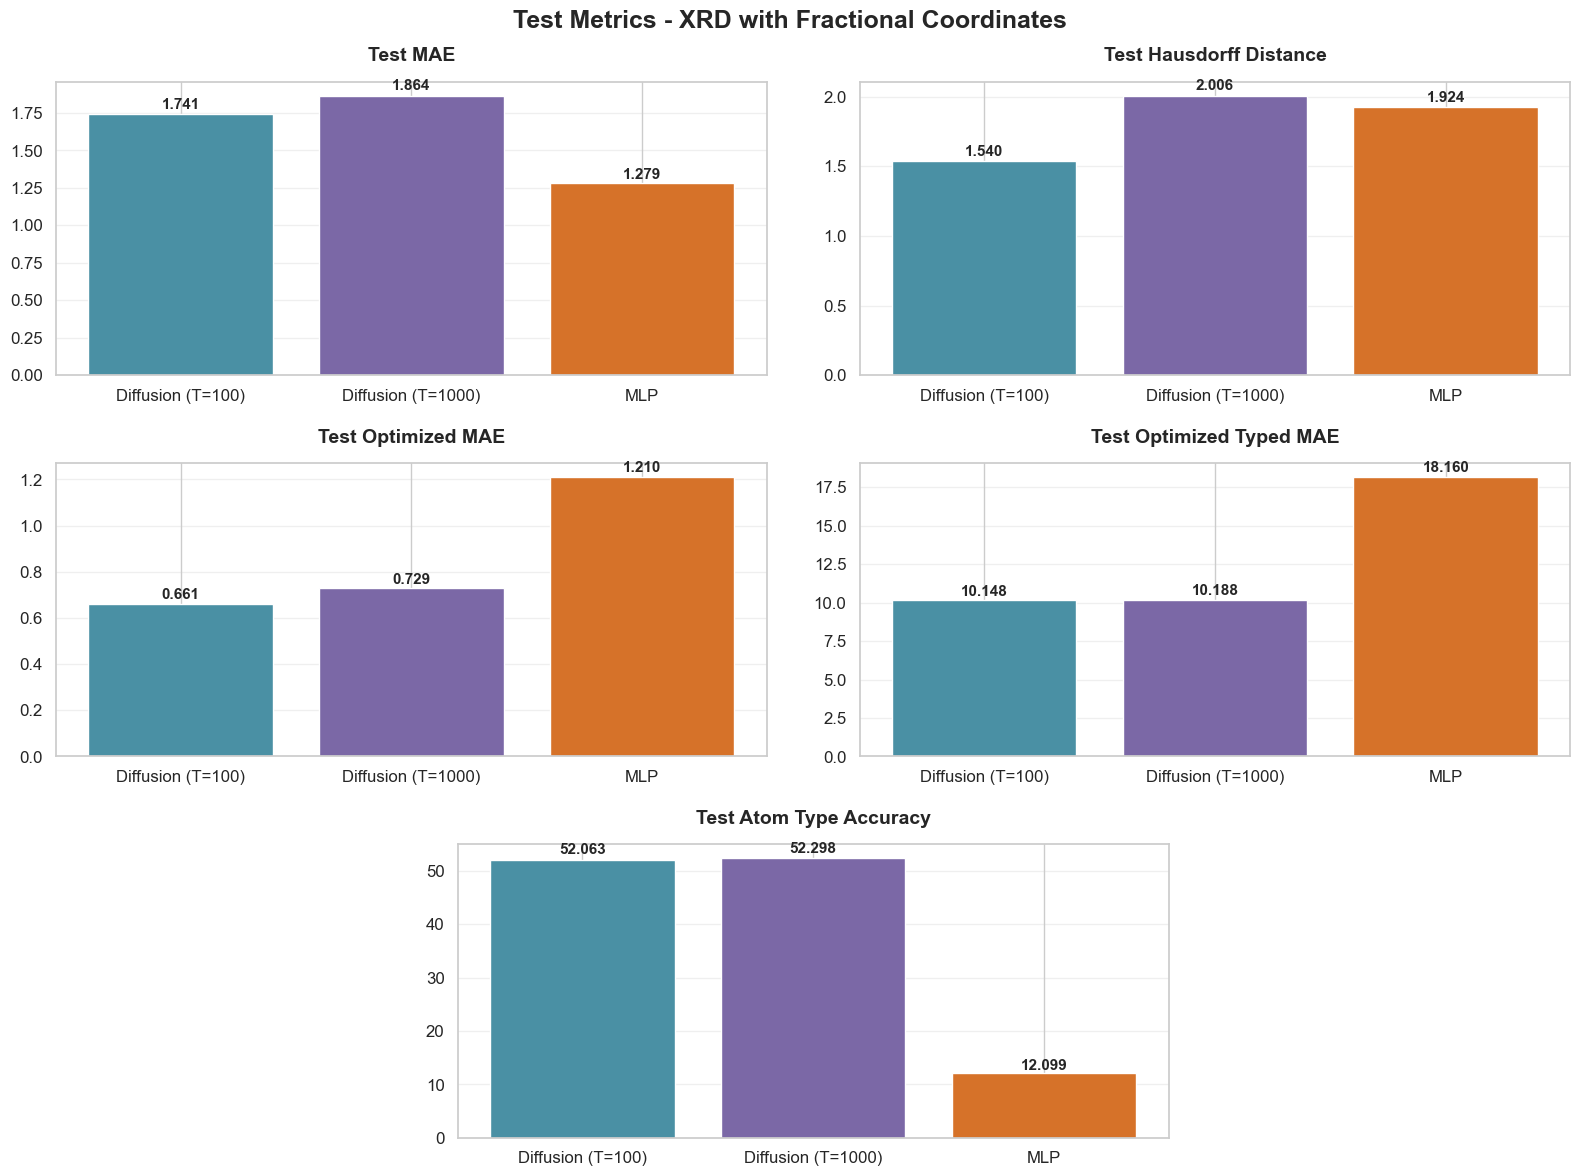

In [46]:
# Cell 19: Improved Plot for XRD + Fractional Coordinates - Modern Colors
combo = combinations[3]  # XRD + pos_frac
subset_df = df[(df['cond_type'] == combo['cond']) & (df['pos_type'] == combo['pos'])]

if len(subset_df) > 0:
    # Aggregate data by model type
    model_stats = []
    for model in subset_df['model_simple'].unique():
        model_data = subset_df[subset_df['model_simple'] == model]
        stats = {
            'Model': model,
            'Test MAE': model_data['test_mae'].mean(),
            'Test Hausdorff': model_data['test_hausdorff'].mean() if model_data['test_hausdorff'].notna().any() else 0,
            'Test Optimized MAE': model_data['test_optimized_mae'].mean() if model_data['test_optimized_mae'].notna().any() else 0,
            'Test Optimized Typed MAE': model_data['test_optimized_typed_mae'].mean() if model_data['test_optimized_typed_mae'].notna().any() else 0,
            'Test Atom Type Accuracy': model_data['test_atom_type_accuracy'].mean() if model_data['test_atom_type_accuracy'].notna().any() else 0,
        }
        model_stats.append(stats)
    
    model_df = pd.DataFrame(model_stats)
    
    # Create the plot using subplot2grid
    fig = plt.figure(figsize=(16, 12))
    colors = ['#4A90A4', '#7B68A6', '#D67229']  # Modern muted colors
    
    # Row 1
    ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=2)
    bars1 = ax1.bar(model_df['Model'], model_df['Test MAE'], color=colors[:len(model_df)])
    ax1.set_title('Test MAE', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars1, model_df['Test MAE']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
    bars2 = ax2.bar(model_df['Model'], model_df['Test Hausdorff'], color=colors[:len(model_df)])
    ax2.set_title('Test Hausdorff Distance', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars2, model_df['Test Hausdorff']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 2
    ax3 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
    bars3 = ax3.bar(model_df['Model'], model_df['Test Optimized MAE'], color=colors[:len(model_df)])
    ax3.set_title('Test Optimized MAE', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars3, model_df['Test Optimized MAE']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax4 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
    bars4 = ax4.bar(model_df['Model'], model_df['Test Optimized Typed MAE'], color=colors[:len(model_df)])
    ax4.set_title('Test Optimized Typed MAE', fontsize=14, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars4, model_df['Test Optimized Typed MAE']):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Row 3 (centered, same size)
    ax5 = plt.subplot2grid((3, 4), (2, 1), colspan=2)
    bars5 = ax5.bar(model_df['Model'], model_df['Test Atom Type Accuracy'], color=colors[:len(model_df)])
    ax5.set_title('Test Atom Type Accuracy', fontsize=14, fontweight='bold', pad=15)
    ax5.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars5, model_df['Test Atom Type Accuracy']):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    fig.suptitle(f'Test Metrics - {combo["title"]}', 
                fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
    plt.show()
else:
    print(f"No data found for {combo['title']}")

In [29]:
# Cell 16.5: Check DataFrame structure first
print("Available columns in DataFrame:")
print(df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Available columns in DataFrame:
['run_id', 'run_name', 'tags', 'state', 'model_type', 'cond_type', 'pos_type', 'T', 'epochs', 'batch_size', 'learning_rate', 'test_mae', 'test_hausdorff', 'test_optimized_mae', 'test_optimized_typed_mae', 'test_atom_type_accuracy', 'model_config', 'model_simple']

DataFrame shape: (12, 18)

First few rows:
     run_id              run_name                                tags   state  \
0  vnr2a96k  structure-prediction  [CHILI, diffusion, job_6190, xPDF]  failed   
1  amnd3t3c  structure-prediction  [CHILI, diffusion, job_6190, xPDF]  failed   
2  zstf3wb4  structure-prediction  [CHILI, diffusion, job_6190, xPDF]  failed   
3  y2talnm9  structure-prediction   [CHILI, diffusion, job_6190, xrd]  failed   
4  l9zn7ftg  structure-prediction   [CHILI, diffusion, job_6190, xrd]  failed   

  model_type cond_type  pos_type       T  epochs  batch_size  learning_rate  \
0  Diffusion      xPDF   pos_abs  1000.0     300          64         0.0001   
1  Diffusion   

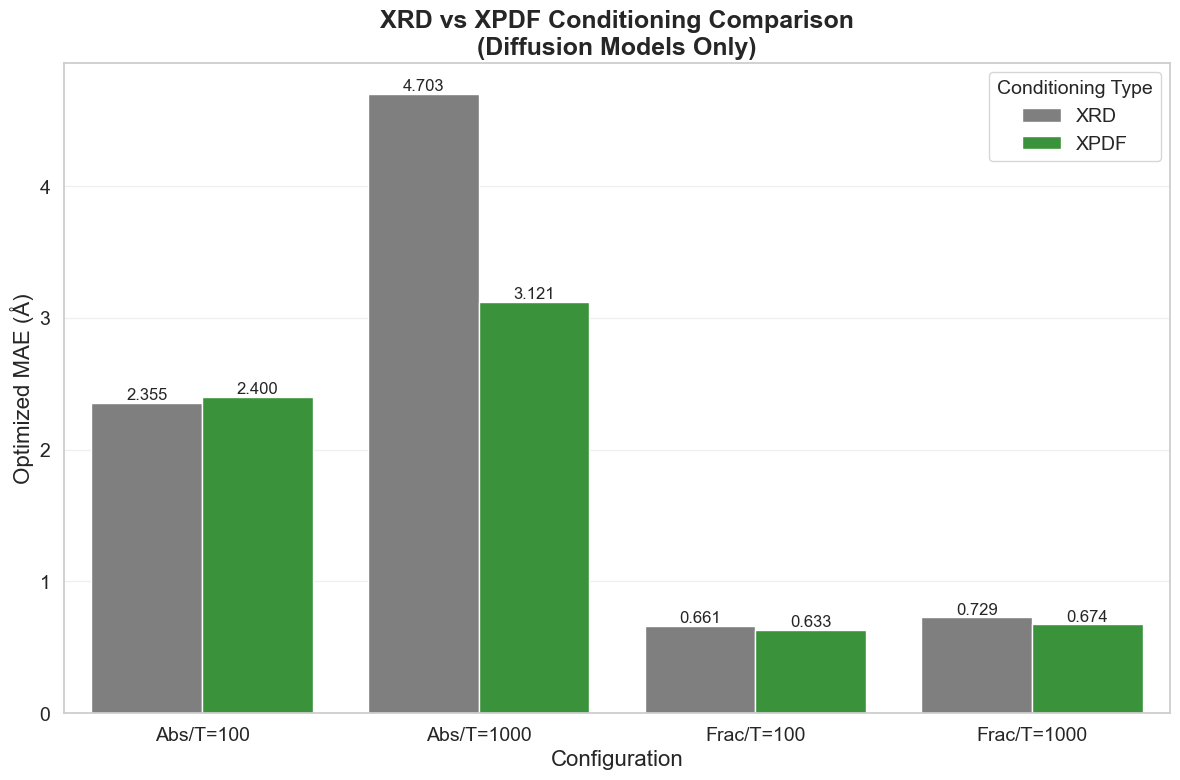

In [ ]:
# Cell 17: XRD vs XPDF Comparison - BIGGER FONTS
def plot_xrd_vs_xpdf_diffusion():
    """Compare XRD vs XPDF conditioning for diffusion models only"""
    
    # Filter for diffusion models only
    diffusion_runs = df[df['model_type'] == 'Diffusion']
    
    if len(diffusion_runs) == 0:
        print("No diffusion runs found for XRD vs XPDF comparison")
        return
    
    # Separate XRD and XPDF runs
    xrd_runs = diffusion_runs[diffusion_runs['cond_type'] == 'xrd']
    xpdf_runs = diffusion_runs[diffusion_runs['cond_type'] == 'xPDF']
    
    # Group by position type and diffusion steps for comparison
    comparison_data = []
    
    for pos_type in ['pos_abs', 'pos_frac']:
        for steps in [100.0, 1000.0]:
            xrd_subset = xrd_runs[(xrd_runs['pos_type'] == pos_type) & (xrd_runs['T'] == steps)]
            xpdf_subset = xpdf_runs[(xpdf_runs['pos_type'] == pos_type) & (xpdf_runs['T'] == steps)]
            
            # Clean up labels
            pos_label = pos_type.replace('pos_', '').title()
            config_label = f'{pos_label}/T={int(steps)}'
            
            if not xrd_subset.empty:
                comparison_data.append({
                    'Configuration': config_label,
                    'Conditioning': 'XRD',
                    'MAE': xrd_subset['test_optimized_mae'].iloc[0]
                })
            
            if not xpdf_subset.empty:
                comparison_data.append({
                    'Configuration': config_label,
                    'Conditioning': 'XPDF', 
                    'MAE': xpdf_subset['test_optimized_mae'].iloc[0]
                })
    
    if not comparison_data:
        print("No matching diffusion runs found for comparison")
        return
        
    comparison_df = pd.DataFrame(comparison_data)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=comparison_df, x='Configuration', y='MAE', hue='Conditioning', 
                palette=['#7f7f7f', '#2ca02c'])  # Gray for XRD, Green for XPDF
    
    plt.title('XRD vs XPDF Conditioning\n(Diffusion Models Only)', fontsize=18, fontweight='bold')
    plt.ylabel('Optimized MAE (Å)', fontsize=16)
    plt.xlabel('Configuration', fontsize=16)
    plt.xticks(rotation=0, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(title='Conditioning Type', fontsize=14, title_fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%.3f', fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_xrd_vs_xpdf_diffusion()

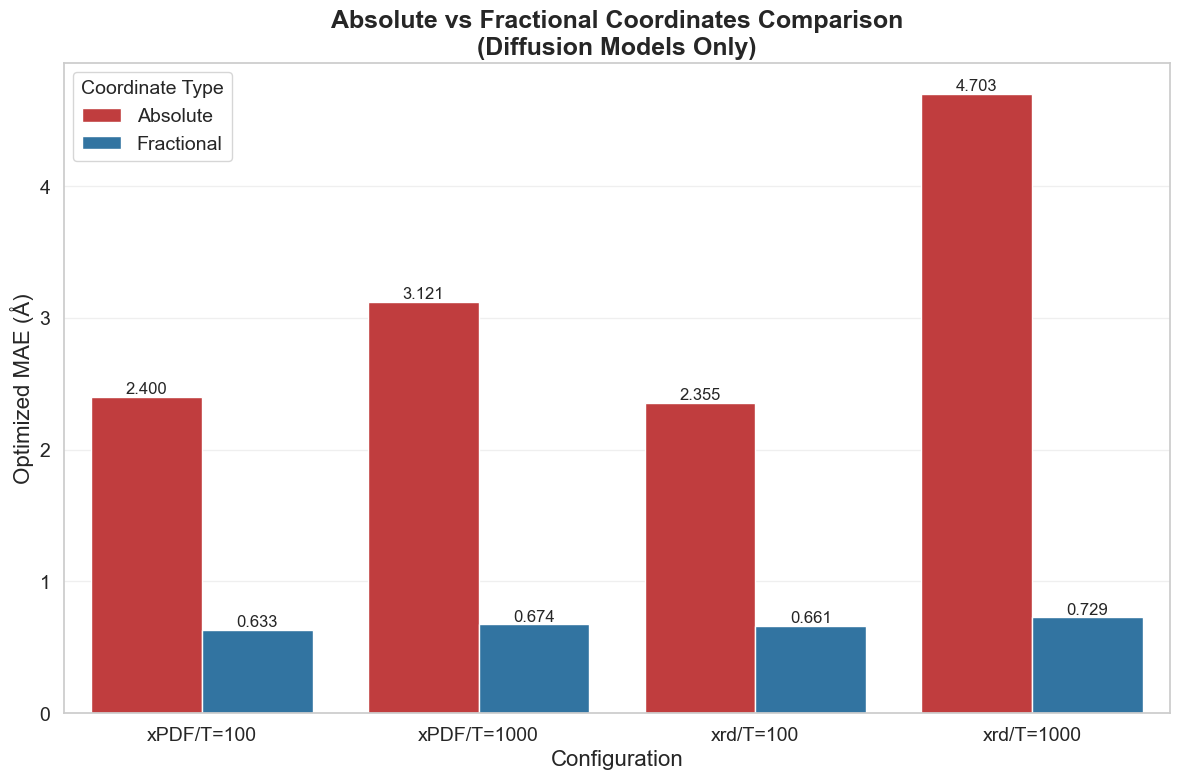

In [ ]:
# Cell 18: Absolute vs Fractional Coordinates Comparison - BIGGER FONTS
def plot_abs_vs_frac_diffusion():
    """Compare absolute vs fractional coordinates for diffusion models only"""
    
    # Filter for diffusion models only
    diffusion_runs = df[df['model_type'] == 'Diffusion']
    
    if len(diffusion_runs) == 0:
        print("No diffusion runs found for abs vs frac comparison")
        return
    
    # Separate abs and frac runs
    abs_runs = diffusion_runs[diffusion_runs['pos_type'] == 'pos_abs']
    frac_runs = diffusion_runs[diffusion_runs['pos_type'] == 'pos_frac']
    
    # Group by conditioning type and diffusion steps for comparison
    comparison_data = []
    
    for cond_type in ['xPDF', 'xrd']:
        for steps in [100.0, 1000.0]:
            abs_subset = abs_runs[(abs_runs['cond_type'] == cond_type) & (abs_runs['T'] == steps)]
            frac_subset = frac_runs[(frac_runs['cond_type'] == cond_type) & (frac_runs['T'] == steps)]
            
            config_label = f'{cond_type}/T={int(steps)}'
            
            if not abs_subset.empty:
                comparison_data.append({
                    'Configuration': config_label,
                    'Coordinates': 'Absolute',
                    'MAE': abs_subset['test_optimized_mae'].iloc[0]
                })
            
            if not frac_subset.empty:
                comparison_data.append({
                    'Configuration': config_label,
                    'Coordinates': 'Fractional',
                    'MAE': frac_subset['test_optimized_mae'].iloc[0]
                })
    
    if not comparison_data:
        print("No matching diffusion runs found for comparison")
        return
        
    comparison_df = pd.DataFrame(comparison_data)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=comparison_df, x='Configuration', y='MAE', hue='Coordinates',
                palette=['#d62728', '#1f77b4'])  # Red for Absolute, Blue for Fractional
    
    plt.title('Absolute vs Fractional Coordinates\n(Diffusion Models Only)', fontsize=18, fontweight='bold')
    plt.ylabel('Optimized MAE (Å)', fontsize=16)
    plt.xlabel('Configuration', fontsize=16)
    plt.xticks(rotation=0, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(title='Coordinate Type', fontsize=14, title_fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%.3f', fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_abs_vs_frac_diffusion()

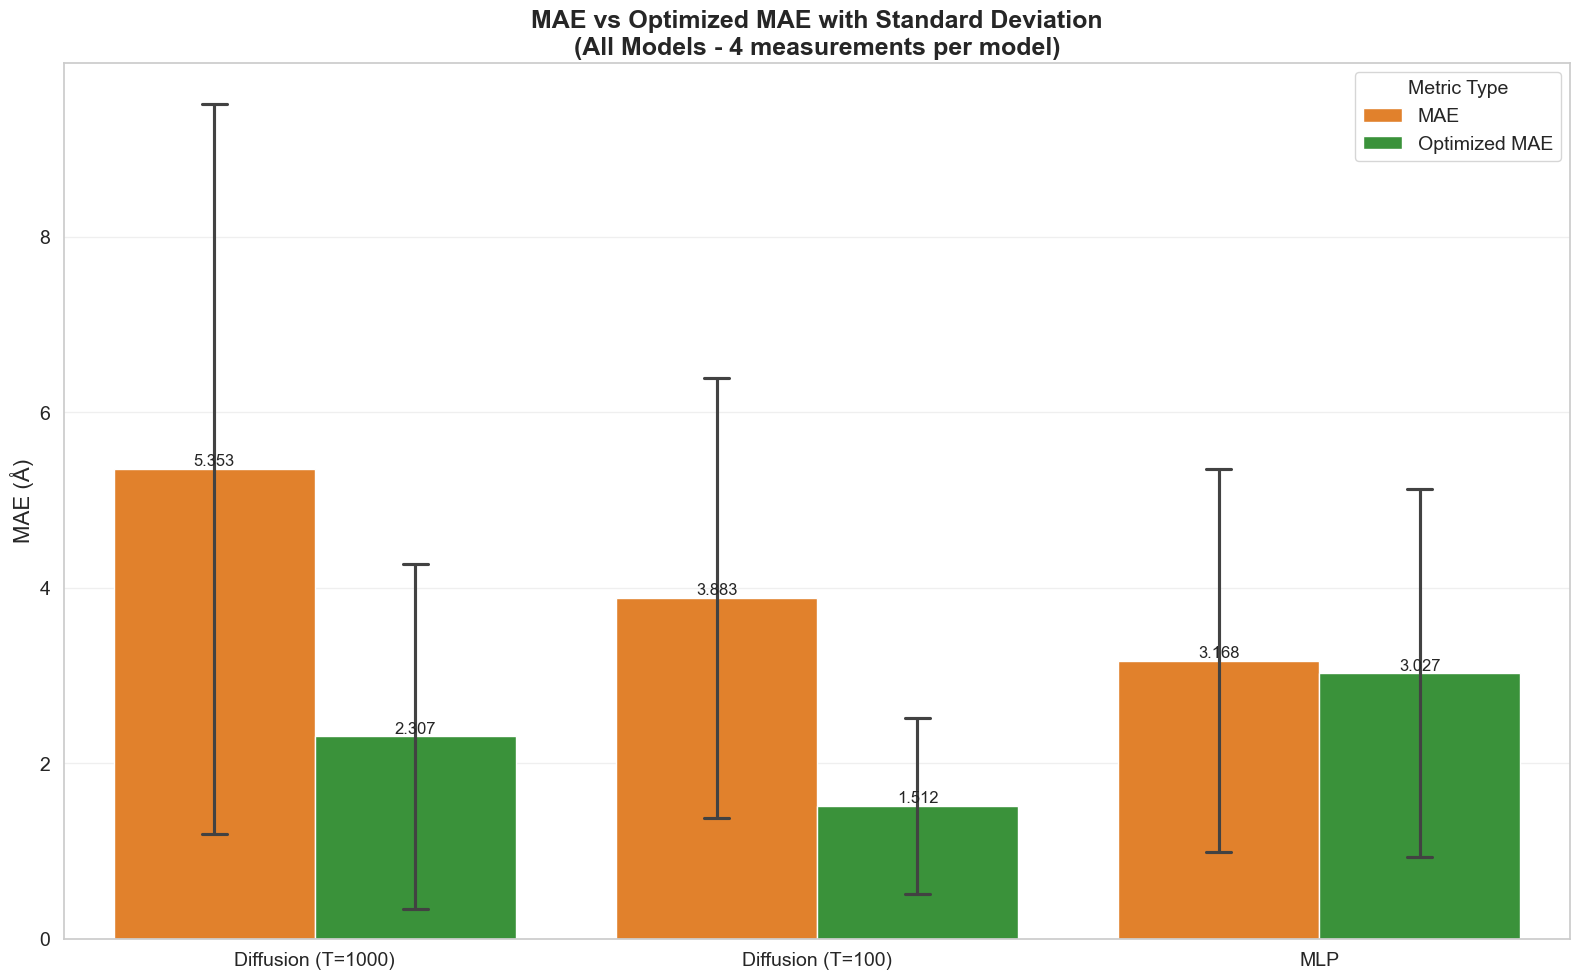

In [ ]:
# Cell 19: MAE vs Optimized MAE Comparison - BIGGER FONTS
def plot_mae_vs_optimized_mae():
    """Compare MAE vs Optimized MAE for all models with variance/error bars"""
    
    # Create model identifier function for your data structure
    def get_model_identifier_corrected(row):
        if row['model_type'] == 'MLP':
            return 'MLP'
        else:  # Diffusion
            return f'Diffusion (T={int(row["T"])})'
    
    # Prepare data for comparison - keep all individual measurements
    comparison_data = []
    
    for _, row in df.iterrows():
        model_id = get_model_identifier_corrected(row)
        
        # Add regular MAE
        comparison_data.append({
            'Model': model_id,
            'Metric Type': 'MAE',
            'Value': row['test_mae'],
            'Configuration': f"{row['cond_type']}/{row['pos_type'].replace('pos_', '')}"
        })
        
        # Add optimized MAE  
        comparison_data.append({
            'Model': model_id,
            'Metric Type': 'Optimized MAE',
            'Value': row['test_optimized_mae'],
            'Configuration': f"{row['cond_type']}/{row['pos_type'].replace('pos_', '')}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    plt.figure(figsize=(16, 10))
    
    # Use seaborn barplot with confidence intervals
    sns.barplot(data=comparison_df, x='Model', y='Value', hue='Metric Type',
                palette=['#ff7f0e', '#2ca02c'],  # Orange for MAE, Green for Optimized MAE
                ci='sd',  # Show standard deviation as error bars
                capsize=0.1)  # Add caps to error bars
    
    plt.title('MAE vs Optimized MAE with Standard Deviation', fontsize=18, fontweight='bold')
    plt.ylabel('MAE (Å)', fontsize=16)
    plt.xlabel('', fontsize=16)
    plt.xticks(rotation=0, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(title='Metric Type', fontsize=14, title_fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars (mean values)
    for container in plt.gca().containers:
        # Get the mean values for labeling
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append(f'{height:.3f}')
        plt.gca().bar_label(container, labels=labels, fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_mae_vs_optimized_mae()

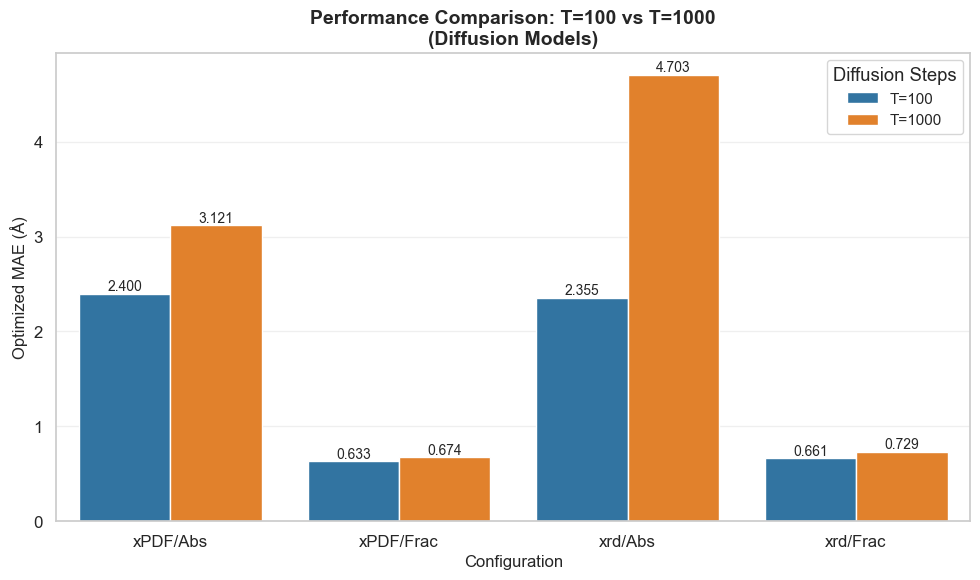


Performance Summary:
Average MAE T=100:  1.5123 Å
Average MAE T=1000: 2.3069 Å
Performance difference: 0.7946 Å (52.5%)

💡 Conclusion: T=100 actually performs better than T=1000


In [35]:
# Cell 20: T=1000 vs T=100 Performance Comparison - CORRECTED (Performance only)
def plot_diffusion_steps_comparison():
    """Compare T=1000 vs T=100 diffusion models performance"""
    
    # Filter for diffusion models only
    diffusion_runs = df[df['model_type'] == 'Diffusion']
    
    if len(diffusion_runs) == 0:
        print("No diffusion runs found for T comparison")
        return
    
    # Separate T=100 and T=1000 runs
    t100_runs = diffusion_runs[diffusion_runs['T'] == 100.0]
    t1000_runs = diffusion_runs[diffusion_runs['T'] == 1000.0]
    
    # Group by conditioning and position type for comparison
    comparison_data = []
    
    for cond_type in ['xPDF', 'xrd']:
        for pos_type in ['pos_abs', 'pos_frac']:
            t100_subset = t100_runs[(t100_runs['cond_type'] == cond_type) & (t100_runs['pos_type'] == pos_type)]
            t1000_subset = t1000_runs[(t1000_runs['cond_type'] == cond_type) & (t1000_runs['pos_type'] == pos_type)]
            
            # Clean up labels
            pos_label = pos_type.replace('pos_', '').title()
            config_name = f'{cond_type}/{pos_label}'
            
            if not t100_subset.empty:
                comparison_data.append({
                    'Configuration': config_name,
                    'Diffusion Steps': 'T=100',
                    'MAE': t100_subset['test_optimized_mae'].iloc[0]
                })
            
            if not t1000_subset.empty:
                comparison_data.append({
                    'Configuration': config_name,
                    'Diffusion Steps': 'T=1000', 
                    'MAE': t1000_subset['test_optimized_mae'].iloc[0]
                })
    
    if not comparison_data:
        print("No matching diffusion runs found for T comparison")
        return
        
    comparison_df = pd.DataFrame(comparison_data)
    
    # Single plot for performance comparison
    plt.figure(figsize=(10, 6))
    
    sns.barplot(data=comparison_df, x='Configuration', y='MAE', hue='Diffusion Steps',
                palette=['#1f77b4', '#ff7f0e'])  # Blue for T=100, Orange for T=1000
    
    plt.title('Performance Comparison: T=100 vs T=1000\n(Diffusion Models)', fontsize=14, fontweight='bold')
    plt.ylabel('Optimized MAE (Å)', fontsize=12)
    plt.xlabel('Configuration', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Diffusion Steps', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nPerformance Summary:")
    print("="*30)
    
    # Calculate average performance difference
    if not comparison_df.empty:
        t100_avg = comparison_df[comparison_df['Diffusion Steps'] == 'T=100']['MAE'].mean()
        t1000_avg = comparison_df[comparison_df['Diffusion Steps'] == 'T=1000']['MAE'].mean()
        
        print(f"Average MAE T=100:  {t100_avg:.4f} Å")
        print(f"Average MAE T=1000: {t1000_avg:.4f} Å")
        print(f"Performance difference: {abs(t1000_avg - t100_avg):.4f} Å ({abs(t1000_avg - t100_avg)/t100_avg*100:.1f}%)")
        
        if abs(t1000_avg - t100_avg) < 0.01:  # Less than 0.01 Å difference
            print("\n💡 Conclusion: T=1000 and T=100 provide similar performance")
        elif t100_avg < t1000_avg:
            print("\n💡 Conclusion: T=100 actually performs better than T=1000")
        else:
            print(f"\n💡 Conclusion: T=1000 provides {(t100_avg - t1000_avg)/t100_avg*100:.1f}% better performance than T=100")

plot_diffusion_steps_comparison()

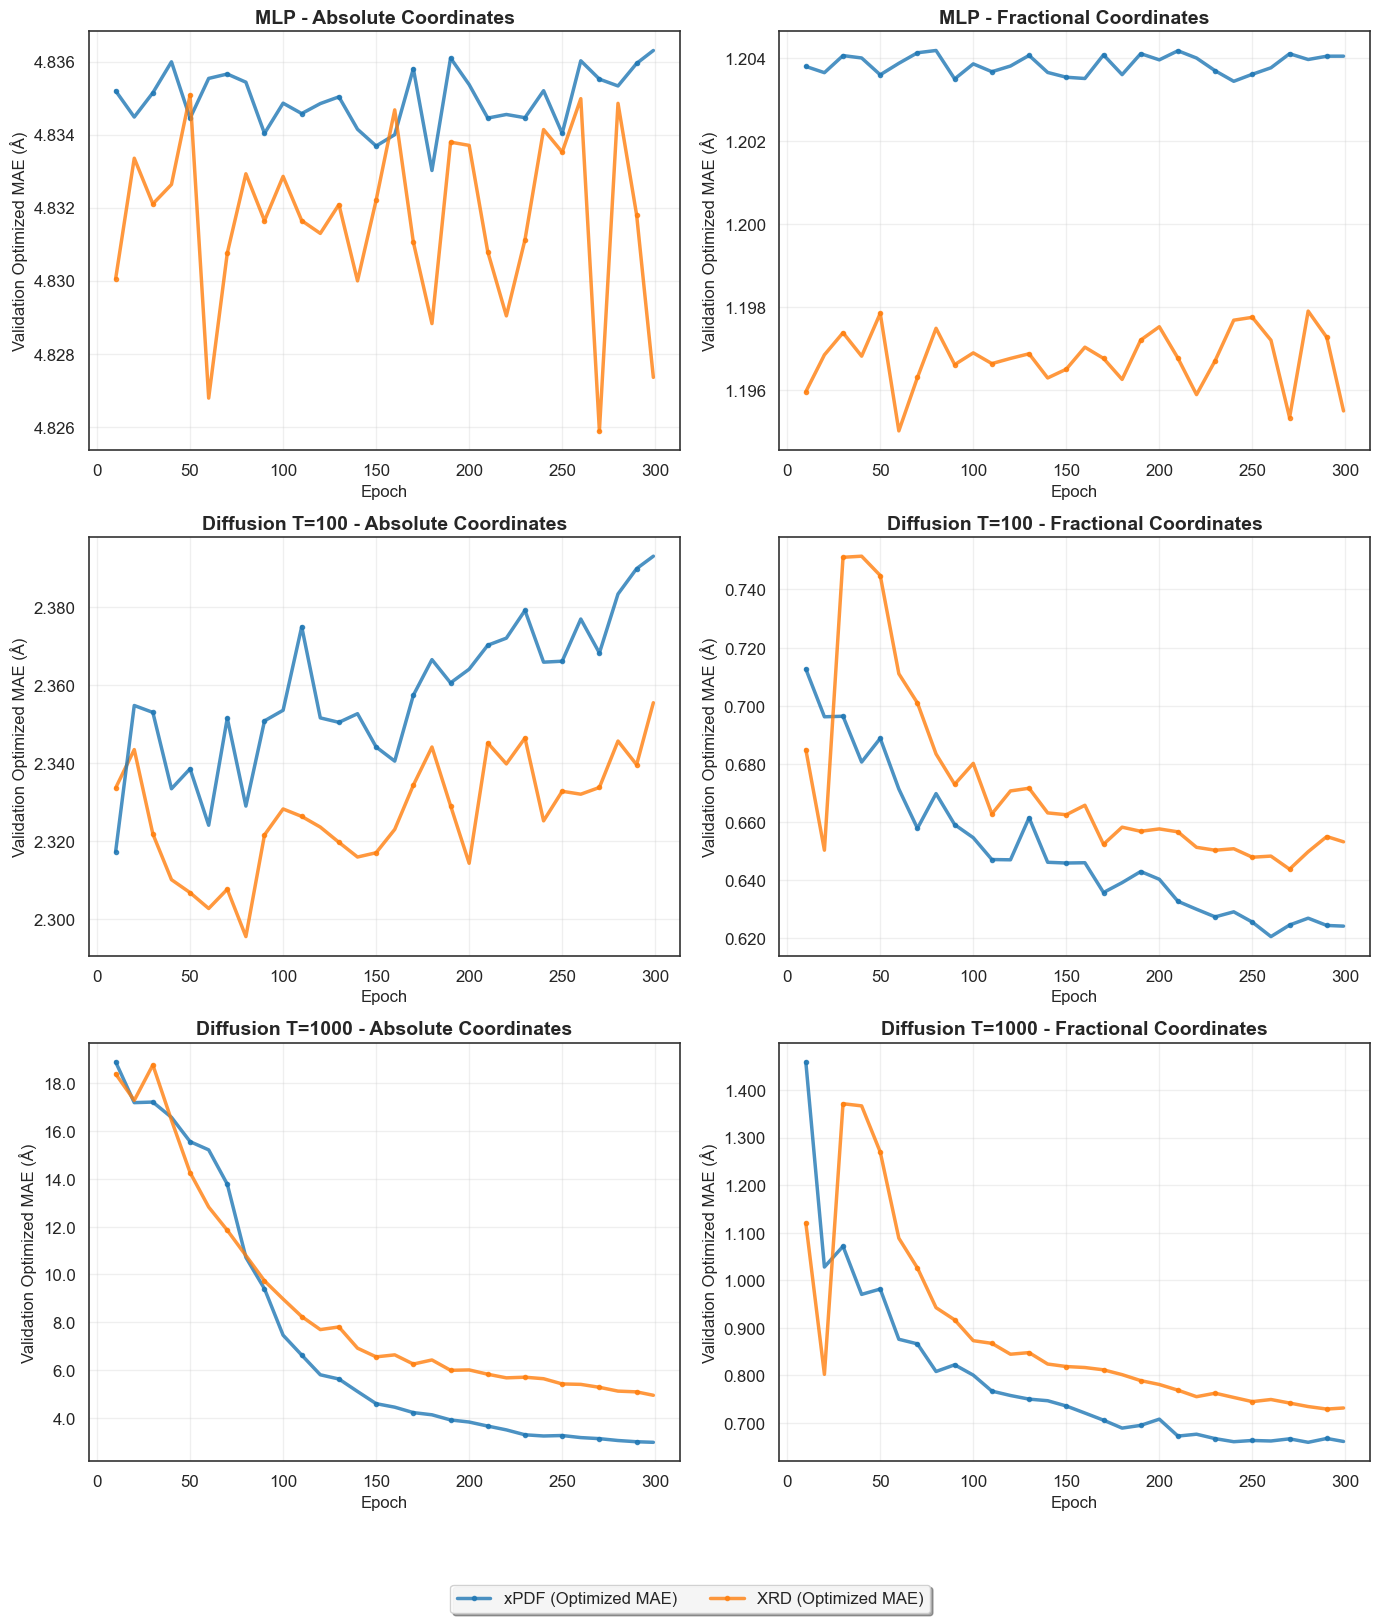


Validation Loss Analysis by Model Type and Position Type:
📊 Left column: Absolute coordinates
📊 Right column: Fractional coordinates
📊 Row 1: MLP models
📊 Row 2: Diffusion T=100 models
📊 Row 3: Diffusion T=1000 models
🎯 Using ONLY Optimized MAE (with Kabsch alignment)
🎨 Consistent colors: Blue = xPDF, Orange = XRD
📍 Centralized legend at bottom


In [55]:
# Cell 21: Validation Loss Curves - OPTIMIZED MAE ONLY with Centralized Legend
def plot_validation_loss_curves():
    """Plot validation curves using ONLY optimized MAE with centralized legend and consistent colors"""
    
    # Create subplots - 3 rows, 2 columns
    fig, axes = plt.subplots(3, 2, figsize=(14, 16))
    
    # Define consistent color mapping for conditioning types
    color_map = {
        'xPDF': '#1f77b4',  # Blue for xPDF (consistent across all plots)
        'xrd': '#ff7f0e'    # Orange for XRD (consistent across all plots)
    }
    
    # Track legend elements for centralized legend
    legend_elements = {}
    
    def plot_validation_curves_for_combination(runs_df, ax, title):
        """Helper function to plot validation curves for a specific model/position combination"""
        
        if len(runs_df) == 0:
            ax.text(0.5, 0.5, f'No runs found', 
                   transform=ax.transAxes, ha='center', va='center', fontsize=12)
            ax.set_title(title, fontsize=14, fontweight='bold')
            return
        
        for _, run_row in runs_df.iterrows():
            run_id = run_row['run_id']
            
            try:
                # Fetch the specific run from wandb
                run = api.run(f"{entity}/{project}/{run_id}")
                
                # Get validation loss history - ONLY optimized MAE
                history = run.scan_history(keys=["val/optimized_mae", "epoch"])
                
                epochs = []
                val_opt_mae = []
                
                for row in history:
                    if 'epoch' in row and 'val/optimized_mae' in row:
                        if row.get('val/optimized_mae') is not None:
                            epochs.append(row.get('epoch', 0))
                            val_opt_mae.append(row.get('val/optimized_mae'))
                
                if len(epochs) > 0 and len(val_opt_mae) > 0:
                    # Get conditioning type and use consistent color
                    cond_type = run_row['cond_type']
                    color = color_map.get(cond_type, '#7f7f7f')  # Default gray if not found
                    
                    # Create label for legend (store only unique ones)
                    if cond_type == 'xPDF':
                        legend_label = 'xPDF (Optimized MAE)'
                    else:
                        legend_label = 'XRD (Optimized MAE)'
                    
                    # Plot with consistent colors - ONLY optimized MAE
                    line = ax.plot(epochs, val_opt_mae, 
                                  color=color, 
                                  linewidth=2.5, alpha=0.8,
                                  marker='o', markersize=3, markevery=max(1, len(epochs)//15))[0]
                    
                    # Store legend element (avoid duplicates)
                    if legend_label not in legend_elements:
                        legend_elements[legend_label] = line
                        
            except Exception as e:
                print(f"Could not fetch data for run {run_id}: {e}")
                continue
        
        # Styling
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Validation Optimized MAE (Å)', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('white')
        
        # Format y-axis to show reasonable number of decimal places
        from matplotlib.ticker import FormatStrFormatter
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        
        # Auto-adjust y-axis formatting based on data range
        ymin, ymax = ax.get_ylim()
        if ymax - ymin > 10:  # Large range
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        elif ymax - ymin > 1:  # Medium range  
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        else:  # Small range
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        
        # Style the plot borders and spines
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_color('#333333')
    
    # Filter data for each combination
    mlp_abs = df[(df['model_type'] == 'MLP') & (df['pos_type'] == 'pos_abs')]
    mlp_frac = df[(df['model_type'] == 'MLP') & (df['pos_type'] == 'pos_frac')]
    
    diff_t100_abs = df[(df['model_type'] == 'Diffusion') & (df['T'] == 100.0) & (df['pos_type'] == 'pos_abs')]
    diff_t100_frac = df[(df['model_type'] == 'Diffusion') & (df['T'] == 100.0) & (df['pos_type'] == 'pos_frac')]
    
    diff_t1000_abs = df[(df['model_type'] == 'Diffusion') & (df['T'] == 1000.0) & (df['pos_type'] == 'pos_abs')]
    diff_t1000_frac = df[(df['model_type'] == 'Diffusion') & (df['T'] == 1000.0) & (df['pos_type'] == 'pos_frac')]
    
    # Plot each combination in 3 rows, 2 columns
    # Row 1: MLP
    plot_validation_curves_for_combination(mlp_abs, axes[0, 0], 'MLP - Absolute Coordinates')
    plot_validation_curves_for_combination(mlp_frac, axes[0, 1], 'MLP - Fractional Coordinates')
    
    # Row 2: Diffusion T=100
    plot_validation_curves_for_combination(diff_t100_abs, axes[1, 0], 'Diffusion T=100 - Absolute Coordinates')
    plot_validation_curves_for_combination(diff_t100_frac, axes[1, 1], 'Diffusion T=100 - Fractional Coordinates')
    
    # Row 3: Diffusion T=1000
    plot_validation_curves_for_combination(diff_t1000_abs, axes[2, 0], 'Diffusion T=1000 - Absolute Coordinates')
    plot_validation_curves_for_combination(diff_t1000_frac, axes[2, 1], 'Diffusion T=1000 - Fractional Coordinates')
    
    # Create centralized legend at the bottom
    if legend_elements:
        fig.legend(legend_elements.values(), legend_elements.keys(), 
                  loc='lower center', 
                  bbox_to_anchor=(0.5, -0.02),  # Position below all subplots
                  ncol=len(legend_elements),      # Arrange horizontally
                  fontsize=12,
                  framealpha=0.9, 
                  fancybox=True, 
                  shadow=True)
    
    # Adjust layout to accommodate centralized legend
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Leave space at the bottom for legend
    plt.show()
    
    # Print summary about what we observe from REAL data
    print("\nValidation Loss Analysis by Model Type and Position Type:")
    print("="*60)
    print("📊 Left column: Absolute coordinates")
    print("📊 Right column: Fractional coordinates") 
    print("📊 Row 1: MLP models")
    print("📊 Row 2: Diffusion T=100 models")
    print("📊 Row 3: Diffusion T=1000 models")
    print("🎯 Using ONLY Optimized MAE (with Kabsch alignment)")
    print("🎨 Consistent colors: Blue = xPDF, Orange = XRD")
    print("📍 Centralized legend at bottom")

# Use ONLY real data from wandb
try:
    api = wandb.Api()
    project = "cluster-structure-prediction"  # Update with your project name
    entity = "kirdon6-university-of-copenhagen"  # Update with your entity name
    plot_validation_loss_curves()
except Exception as e:
    print(f"Error setting up wandb API: {e}")
    print("Make sure you have wandb configured and the correct project/entity names")